In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import os
from perturbgen.configs import ROOT
from pathlib import Path
import datetime
import random
from matplotlib import style
# import f1 score and accuracy
from sklearn.metrics import balanced_accuracy_score
import gseapy as gp

import pooch
import zipfile
from tqdm import tqdm
import hashlib

In [2]:
os.chdir(ROOT)

In [3]:
date = datetime.datetime.now().strftime("%Y%m%d")
# %%
np.random.seed(42)
random.seed(42)

In [4]:
style.use('default')
style.use(
    '/lustre/scratch126/cellgen/lotfollahi/kl11/'
    'T_perturb/perturbgen/pp/mpl_style.mplstyle'
)

In [5]:
res_dir = '/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/tf_perturbation'
# create directory if it does not exist
if not os.path.exists(res_dir):
    os.makedirs(res_dir)


### 1. Load Data

In [6]:
tf_data = sc.read_h5ad('/nfs/team361/am74/Cytomeister/Evaluation_datasets/HSPC_invitro_perturbseq/processed_data.h5ad')

In [7]:
# load GATA1 perturbed cells
adata_gata1 = sc.read_h5ad('/nfs/team361/am74/Cytomeister/configs/HSPC/100m/epoch14/20250717-08:51_minference_adata_gGATA1_ssrc_tmask.h5ad')

In [8]:
adata_gata1

AnnData object with n_obs × n_vars = 10577 × 5700
    obs: 'sex', 'phase', 'tissue', 'celltype_v2', 'diff_state', 'cell_idx'
    obsm: 'mean_cos_similarity', 'mean_cos_similarity_l1', 'mean_cos_similarity_lmid', 'perturbed_cls', 'true_cls'
    varm: 'gene_cos_similarity'
    layers: 'pred_counts', 'true_counts'

In [9]:
tf_data = tf_data[:, tf_data.var_names.isin(adata_gata1.var_names)]

In [10]:
excl_celltypes = ['Early GMP', 'MEP', 'EoBasoMast Precursor']
hspc_incl_celltype = ['Early_Ery', 'Late_Ery', 'BaEoMa', 'MK']

In [11]:
tf_filtered = tf_data[~tf_data.obs['new_CellType'].isin(excl_celltypes)]
tf_filtered.X = tf_filtered.layers['counts'].copy()
# log normalize
sc.pp.normalize_total(tf_filtered)
sc.pp.log1p(tf_filtered)

/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [12]:
tf_filtered

AnnData object with n_obs × n_vars = 82100 × 3921
    obs: 'batch', 'perturbation', 'replicate', 'Timepoint', 'nCount_RNA', 'nFeature_RNA', 'nCount_atac', 'nFeature_atac', 'perturbation_name', 'target', 'new_CellType', 'annotation_simplified', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells'
    uns: 'log1p'
    layers: 'counts'

In [13]:
sc.tl.rank_genes_groups(
    tf_filtered,
    group="GATA1",
    groupby="target",
    reference='NT',
    method="wilcoxon",
)
tf_deg_df = sc.get.rank_genes_groups_df(tf_filtered, group="GATA1")

In [14]:
# extract ranking statistics for genes in degs_filtered_df
tf_gata1_ranks = pd.DataFrame({
    'gene': tf_deg_df['names'],
    'scores': tf_deg_df['scores'],
})
tf_gata1_ranks.index = tf_gata1_ranks['gene']
tf_gata1_ranks.drop(columns=['gene'], inplace=True)
tf_gata1_ranks.index.name = None
# sorting by scores
tf_gata1_ranks = tf_gata1_ranks.sort_values('scores', ascending=False)

In [15]:
tf_gata1_ranks

,scores
ELMO1,9.260726
PTPRC,8.863856
TNIK,8.655834
LGALS1,8.515960
TPM4,8.467190
...,...
BLVRB,-9.565270
PRDX2,-9.805930
TLCD4,-9.829534
TFRC,-10.260821


In [16]:
adata_gata1 = adata_gata1[adata_gata1.obs['celltype_v2'].isin(hspc_incl_celltype)] 
adata_gata1 = adata_gata1[:, adata_gata1.var_names.isin(tf_data.var_names)]

pred = adata_gata1.copy()
pred.X = pred.layers['pred_counts'].copy()
pred.obs['status'] = 'predicted'
adata_gata1.obs['status'] = 'perturbed'
adata_gata1 = adata_gata1.concatenate(pred)

sc.pp.normalize_total(adata_gata1)
sc.pp.log1p(adata_gata1)


/tmp/ipykernel_2171756/389406640.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_gata1.obs['status'] = 'perturbed'
/tmp/ipykernel_2171756/389406640.py:8: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_gata1 = adata_gata1.concatenate(pred)


In [17]:
sc.tl.rank_genes_groups(
    adata_gata1,
    group="perturbed",
    groupby="status",
    reference='predicted',
    method="wilcoxon",
)
gata1_deg_df = sc.get.rank_genes_groups_df(adata_gata1, group="perturbed")
# gata1_deg_df = adata_gata1_df[(adata_gata1_df['pvals_adj'] < 0.05) & adata_gata1_df['logfoldchanges'].abs() > 0.25]

In [18]:
# extract ranking statistics for genes in degs_filtered_df
gata1_ranks = pd.DataFrame({
    'gene': gata1_deg_df['names'],
    'scores': gata1_deg_df['scores'],
})
gata1_ranks.index = gata1_ranks['gene']
gata1_ranks.drop(columns=['gene'], inplace=True)
gata1_ranks.index.name = None
# sorting by scores
gata1_ranks = gata1_ranks.sort_values('scores', ascending=False)


In [19]:
# perform GSEA on the ranked genes
go_bio = gp.get_library(name='GO_Biological_Process_2025', organism='Human')
reactome_2024 = gp.get_library(name='Reactome_Pathways_2024', organism='Human')
msigdb = gp.get_library(name='MSigDB_Hallmark_2020', organism='Human')

In [20]:
def break_ties_df_gene_index(
    df: pd.DataFrame,
    score_col: str = "scores",
    eps: float = 1e-12,
    sort_desc: bool = True,
) -> pd.DataFrame:
    """
    Break ties deterministically in a preranked DataFrame where:
      - index = gene
      - df[score_col] = ranking statistic (e.g. 'scores')
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Expected a pandas DataFrame")

    if score_col not in df.columns:
        raise ValueError(f"'{score_col}' not found. Columns are: {list(df.columns)}")

    out = df.copy()
    genes = out.index.astype(str).to_numpy()

    def u01(g: str) -> float:
        h = hashlib.md5(g.encode("utf-8")).hexdigest()[:12]  # stable 32-bit chunk
        return int(h, 16) / 2**32

    jitter = np.array([u01(g) for g in genes], dtype=float)
    out[score_col] = out[score_col].astype(float) + eps * jitter

    if sort_desc:
        out = out.sort_values(score_col, ascending=False)

    return out


In [21]:
tf_gata1_ranks_df = break_ties_df_gene_index(
    tf_gata1_ranks,
    score_col="scores",
    eps=1e-12,
)
gata1_ranks_df = break_ties_df_gene_index(
    gata1_ranks,
    score_col="scores",
    eps=1e-12,
)

In [22]:
LIBS = [
    (go_bio, "GO_Biological_Process_2025"),
    (reactome_2024, "Reactome_Pathways_2024"),
]


def run_prerank(rnk, gene_sets, threads=3, perm=2000, seed=42):
    enr = gp.prerank(
        rnk=rnk,
        threads=threads,
        gene_sets=gene_sets,
        min_size=10,
        max_size=500,
        outdir=None,
        permutation_num=perm,
        seed=seed,
        verbose=False,
    )

    res = enr.res2d.copy()

    # Always keep Term
    keep_cols = ["Term"]

    # Prefer NES if present, otherwise fall back to ES
    if "NES" in res.columns:
        keep_cols.append("NES")
    elif "ES" in res.columns:
        keep_cols.append("ES")

    # Keep FDR only if it exists (perm > 0)
    if "FDR q-val" in res.columns:
        keep_cols.append("FDR q-val")

    # Lead genes are optional but nice
    if "Lead_genes" in res.columns:
        keep_cols.append("Lead_genes")

    return res[keep_cols].copy()

In [23]:
# 1) REAL dataset GSEA (used to define S)
gsea_real = {}
for gene_set, name in LIBS:
    gsea_real[name] = run_prerank(tf_gata1_ranks_df, gene_set, perm=2000, seed=0, threads=2)
    print(name, "real significant:", (gsea_real[name]["FDR q-val"] < 0.05).sum())

GO_Biological_Process_2025 real significant: 35
Reactome_Pathways_2024 real significant: 108


In [24]:
gsea_results_filtered = {}
for name, df in gsea_real.items():
    # filter df for FDR < 0.25 in both
    gsea_results_filtered[name] = df[df["FDR q-val"] < 0.05]
    print(f"{name}: {gsea_results_filtered[name].shape[0]} significant pathways found.")

GO_Biological_Process_2025: 35 significant pathways found.
Reactome_Pathways_2024: 108 significant pathways found.


In [25]:
gsea_pred_obs = {}
for gene_set, name in LIBS:
    gsea_pred_obs[name] = run_prerank(gata1_ranks_df, gene_set, perm=10, seed=0, threads=8)

In [26]:
gsea_pred_obs

{'GO_Biological_Process_2025':                                                    Term       NES FDR q-val  \
 0     Negative Regulation of Cytokine-Mediated Signa...    2.1863       0.0   
 1         Regulation of Cell Cycle Process (GO:0010564) -2.183609       0.0   
 2                             ERAD Pathway (GO:0036503)  2.126504       0.0   
 3     Inorganic Cation Import Across Plasma Membrane... -2.105153       0.0   
 4             Leukocyte Cell-Cell Adhesion (GO:0007159)  2.096081       0.0   
 ...                                                 ...       ...       ...   
 1042          Microtubule Bundle Formation (GO:0001578)  0.483205  0.999555   
 1043      Regulation of Cell Communication (GO:0010646) -0.480707  0.995461   
 1044  Regulation of Release of Sequestered Calcium I...  0.477125  0.998413   
 1045                 Regulation of Anoikis (GO:2000209)  0.440246  0.999594   
 1046  Positive Regulation of Nervous System Developm...  0.424483  0.998456   
 
        

In [27]:
def direction_concordance(real_df, pred_df, fdr=0.05, min_abs_nes_real=None):
    # define S from real only
    S = real_df[real_df["FDR q-val"] < fdr].copy()
    if min_abs_nes_real is not None:
        S = S[S["NES"].abs() >= min_abs_nes_real]

    if S.empty:
        return np.nan, 0

    merged = S[["Term", "NES"]].merge(
        pred_df[["Term", "NES"]],
        on="Term",
        how="inner",
        suffixes=("_real", "_pred"),
    )

    if merged.empty:
        return np.nan, 0
    y_true = (merged["NES_real"].to_numpy() > 0).astype(int)  # 1 = Up, 0 = Down
    y_pred = (merged["NES_pred"].to_numpy() > 0).astype(int)
    
    return balanced_accuracy_score(y_true, y_pred), merged.shape[0]


In [28]:
for name in gsea_real:
    T_obs, n_used = direction_concordance(
        gsea_real[name], gsea_pred_obs[name],
        fdr=0.05,
        min_abs_nes_real=1.0,   # optional but recommended
    )
    print(name, "T_obs:", T_obs, "n_used:", n_used)

GO_Biological_Process_2025 T_obs: 0.7348484848484849 n_used: 35
Reactome_Pathways_2024 T_obs: 0.7559155442300691 n_used: 108


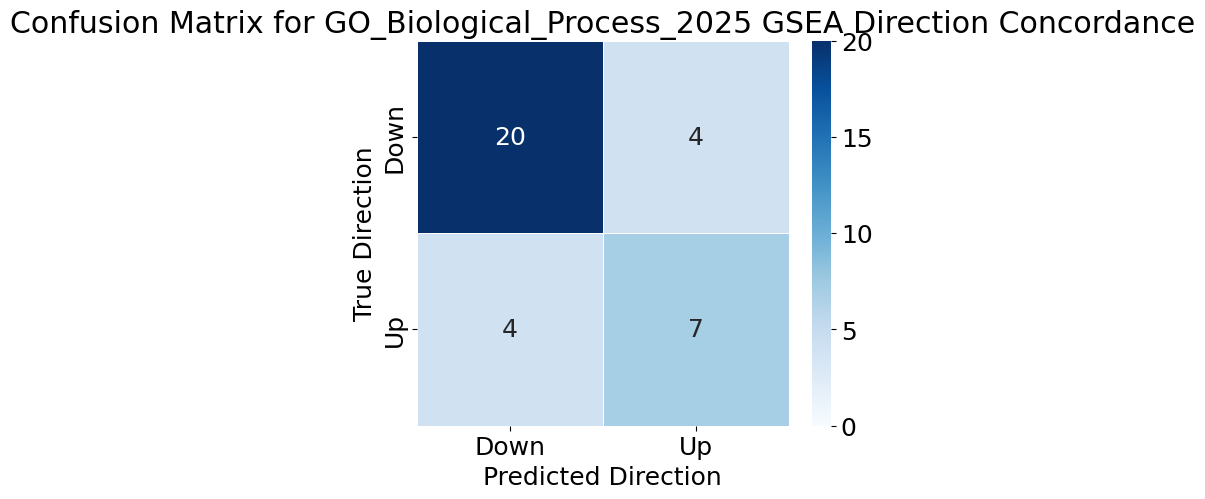

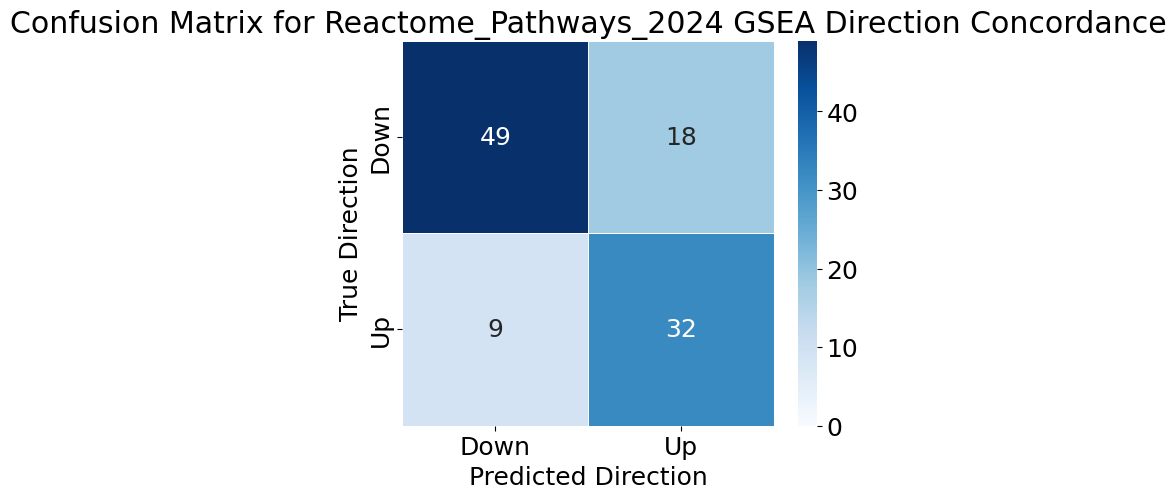

In [29]:
# plot confusion matrix for observed vs real based on direction concordance without any permutation
from sklearn.metrics import confusion_matrix
for name in gsea_real:
    real_df = gsea_real[name]
    pred_df = gsea_pred_obs[name]

    # define S from real only
    S = real_df[real_df["FDR q-val"] < 0.05].copy()
    S = S[S["NES"].abs() >= 1.0]

    merged = S[["Term", "NES"]].merge(
        pred_df[["Term", "NES"]],
        on="Term",
        how="inner",
        suffixes=("_real", "_pred"),
    )


    y_true = np.sign(merged["NES_real"].to_numpy())
    y_pred = np.sign(merged["NES_pred"].to_numpy())
    # convert to int
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True, fmt='d',
        cmap='Blues',
        vmin=0, vmax=cm.max(),
        linewidths=0.5, linecolor='white',
        cbar=True,
        xticklabels=['Down', 'Up'],
        yticklabels=['Down', 'Up'],
    )
    plt.xlabel('Predicted Direction')
    plt.ylabel('True Direction')
    plt.title(f'Confusion Matrix for {name} GSEA Direction Concordance')
    # # save figure
    # plt.savefig(os.path.join(res_dir, f'{date}__gata1_pathway_conf_matrix_dir_concordance_{name.replace(" ", "_")}.pdf'),
    #             bbox_inches='tight')

In [30]:
def permute_gene_labels(rnk, rng):
    # works for DataFrame with first col gene, second col score OR Series with index genes
    if isinstance(rnk, pd.DataFrame):
        genes = rnk.index.to_numpy().flatten()
        scores = rnk['scores'].to_numpy()
        return pd.DataFrame({'scores': scores}, index=rng.permutation(genes))
        # scores = rnk.to_numpy()
        # return pd.Series(scores, index=rng.permutation(genes))

    else:
        raise TypeError("rnk must be a pandas Series or DataFrame")

In [31]:
def permutation_test_for_library(name, gene_set, B=1000, pred_perm=100, seed=123):
    rng = np.random.default_rng(seed)

    real_df = gsea_real[name]
    pred_obs_df = gsea_pred_obs[name]
    T_obs, n_used = direction_concordance(real_df, pred_obs_df, fdr=0.05, min_abs_nes_real=1.0)
    if np.isnan(T_obs) or n_used == 0:
        return None

    T_null = np.empty(B, dtype=float)
    used_terms = set(
        real_df[real_df["FDR q-val"] < 0.05]
        .loc[real_df["NES"].abs() >= 1.0, "Term"]
        .to_numpy()
    )
    gene_set_subset = {
        term: genes
        for term, genes in gene_set.items()
        if term in used_terms
    }
    for b in tqdm(range(B)):
        rnk_perm = permute_gene_labels(gata1_ranks_df, rng)
        pred_perm_df = run_prerank(rnk_perm, gene_set_subset, perm=pred_perm, seed=int(rng.integers(1e9)))
        T_b, _ = direction_concordance(real_df, pred_perm_df, fdr=0.05, min_abs_nes_real=1.0)
        T_null[b] = T_b

    p = (1 + np.sum(T_null >= T_obs)) / (B + 1)
    return {
        "T_obs": T_obs,
        "n_used": n_used,
        "p_emp": p,
        "null_mean": float(T_null.mean()),
        "null_sd": float(T_null.std(ddof=1)),
        "z": float((T_obs - T_null.mean()) / T_null.std(ddof=1)),
        "T_null": T_null,
    }
perm_results = {}

for gene_set, name in LIBS:

    perm_results[name] = permutation_test_for_library(name, gene_set, B=5000, pred_perm=10, seed=0)
    r = perm_results[name]
    print(name, "p_emp:", r["p_emp"], "T_obs:", r["T_obs"], "null_mean:", r["null_mean"])

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [09:20<00:00,  8.91it/s]


GO_Biological_Process_2025 p_emp: 0.041191761647670466 T_obs: 0.7348484848484849 null_mean: 0.4991791666666667


100%|██████████| 5000/5000 [16:45<00:00,  4.97it/s]

Reactome_Pathways_2024 p_emp: 0.021995600879824034 T_obs: 0.7559155442300691 null_mean: 0.500058973425555


In [34]:
# save perm_results as pkl file
import pickle
with open(os.path.join(res_dir, f'{date}_gata1_pathway_permutation_results.pkl'), 'wb') as f:
    pickle.dump(perm_results, f)

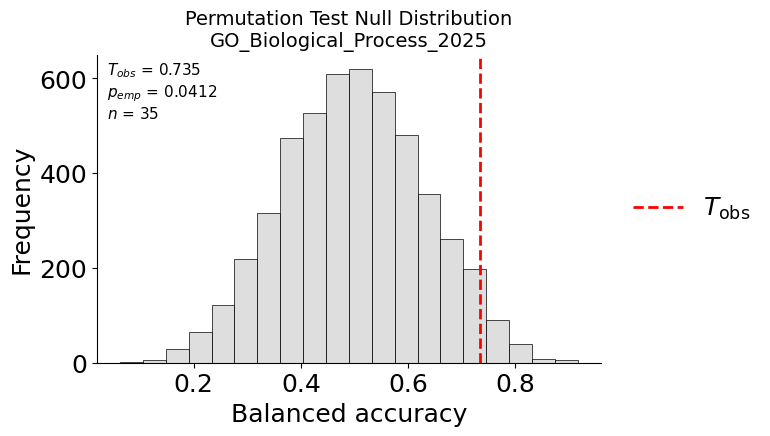

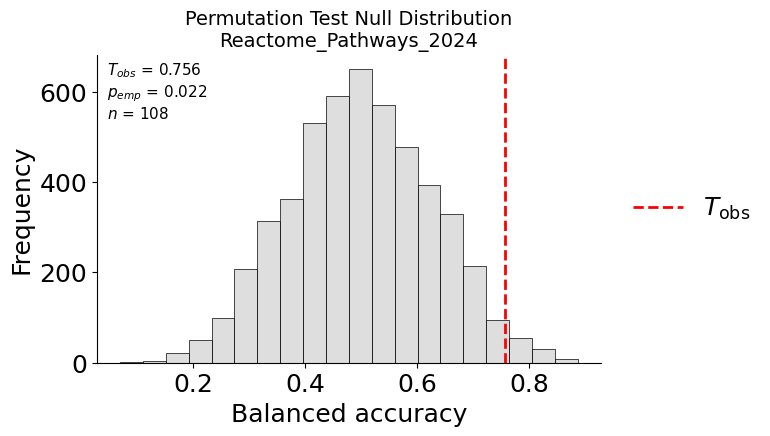

In [ ]:
for name in perm_results:
    r = perm_results[name]
    T_null = r["T_null"]
    T_obs = r["T_obs"]

    plt.figure(figsize=(6.5, 4))

    sns.histplot(
        T_null,
        bins=20,
        color="lightgray",
        edgecolor="black",
        linewidth=0.5
    )

    # observed line
    plt.axvline(
        T_obs,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$T_{\mathrm{obs}}$"
    )

    plt.title(f"Permutation Test Null Distribution\n{name}", fontsize=14)
    plt.xlabel("Balanced accuracy")
    plt.ylabel("Frequency")

    # annotation box in axes coordinates (clean + stable)
    txt = (
        f"$T_{{obs}}$ = {T_obs:.3f}\n"
        f"$p_{{emp}}$ = {r['p_emp']:.3g}\n"
        f"$n$ = {r['n_used']}"
    )

    plt.text(
        0.02, 0.98,
        txt,
        transform=plt.gca().transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        )
    )

    # legend outside the plot
    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

    # save figure
    plt.savefig(
        os.path.join(res_dir, f"{date}_gata1_pathway_histplot_dir_concordance_{name.replace(' ', '_')}.pdf"),
        dpi=300,
        bbox_inches="tight"
    )

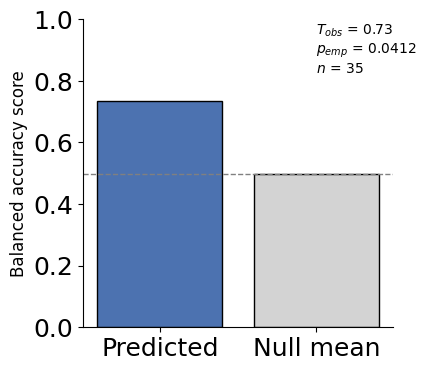

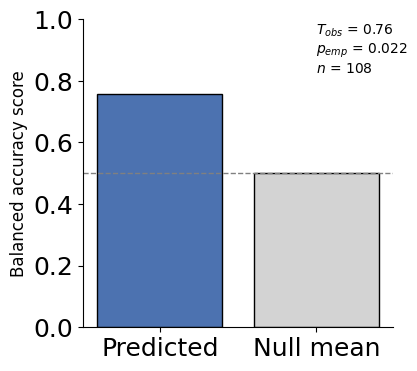

In [36]:
# also plot barplot of observed vs null mean where for null mean also plot std as error bar
for name in perm_results:
    r = perm_results[name]
    T_null = r["T_null"]
    T_obs = r["T_obs"]
    null_mean = r["null_mean"]
    null_sd = r["null_sd"]
    p_emp = r["p_emp"]
    n_used = r['n_used']

    lo, hi = np.percentile(T_null, [2.5, 97.5])
    mu = null_mean

    # asymmetric errors for the null mean bar
    yerr = np.array([[mu - lo], [hi - mu]])

    plt.figure(figsize=(4,4))
    plt.bar(["Predicted", "Null mean"], [T_obs, mu], color=["#4C72B0", "lightgray"], edgecolor="black")
    # plt.errorbar([1], [mu], yerr=yerr, fmt="none", capsize=6, ecolor="black", linewidth=1.5)

    plt.ylim(0, 1)
    plt.ylabel("Balanced accuracy")
# plt.title("Observed vs null (95% interval)")



    # reference line
    plt.axhline(
        null_mean,
        linestyle="--",
        color="gray",
        linewidth=1
    )

    plt.ylabel("Balanced accuracy score", fontsize=12)
    plt.ylim(0, 1)

    # annotation
    plt.text(
        0.75, 0.99,
        f"$T_{{obs}}$ = {T_obs:.2f}\n"
        f"$p_{{emp}}$ = {p_emp:.3g}\n"
        f"$n$ = {n_used}",
        transform=plt.gca().transAxes,
        va="top",
        fontsize=10
    )


    # # save figure
    # plt.savefig(
    #     os.path.join(res_dir, f"{date}_gata1_pathway_barplot_dir_concordance_{name.replace(' ', '_')}.pdf"),
    #     dpi=300,
    #     bbox_inches="tight"
    # )


In [ ]:
# gsea_results = {}
# enr_insilico_gata1_results = {}
# enr_tf_gata1_results = {}
# for gene_set, name in zip([go_bio, reactome_2024, msigdb], ['GO_Biological_Process_2025', 'Reactome_Pathways_2024', 'MSigDB_Hallmark_2020']):
    
#     enr_tf_gata1 = gp.prerank(
#         rnk=tf_gata1_ranks,
#         threads=1,
#         gene_sets=gene_set,
#         min_size=10,
#         max_size=500,
#         outdir=None,
#         permutation_num=5000,  # reduce number to speed up testing
#         seed=42,
#         verbose=True,
#     )
#     enr_insilico_gata1 = gp.prerank(
#         rnk=gata1_ranks,
#         threads=1,
#         gene_sets=gene_set,
#         min_size=10,
#         max_size=500,
#         outdir=None,
#         permutation_num=5000,  # reduce number to speed up testing
#         seed=42,
#         verbose=True,
#     )
#     enr_insilico_gata1_results[name] = enr_insilico_gata1
#     enr_tf_gata1_results[name] = enr_tf_gata1
#     # pick useful columns; rename for clarity
#     cols = ["Term", "NES", "FDR q-val", "Lead_genes"]
#     left  = enr_insilico_gata1.res2d[cols].copy().drop_duplicates("Term")
#     right = enr_tf_gata1.res2d[cols].copy().drop_duplicates("Term")
#     left.columns  = ["Term", "NES_pred", "NES_pred", "Lead_geNES_pred"]
#     right.columns = ["Term", "NES_real",       "FDR_real",       "Lead_geNES_real"]

#     # robust inner join on term
#     cmp_df = (
#         left.merge(right, on="Term", how="inner")
#             .dropna(subset=["NES_pred", "NES_real"])
#     )

#     # optional sanity columns
#     cmp_df["sign_consistent"] = (cmp_df["NES_pred"] * cmp_df["NES_real"]) > 0
#     cmp_df["abs_delta_NES"]   = (cmp_df["NES_pred"] - cmp_df["NES_real"]).abs()

#     float_cols = ["NES_pred", "NES_pred", "NES_real", "FDR_real", "abs_delta_NES"]
#     cmp_df[float_cols] = cmp_df[float_cols].astype(float)

#     gsea_results[name] = cmp_df

In [ ]:
# save GSEA results
gsea_res_dir = Path(res_dir) / 'gsea_results'
gsea_res_dir.mkdir(parents=True, exist_ok=True)
for name, df in gsea_real.items():
    # as csv
    df.to_csv(gsea_res_dir / f'{date}_gsea_real_{name}_GATA1.csv', index=False)

In [ ]:
# merge gsea_real_filtered and gsea_pred_obs into gsea_results_filtered with suffixes _real and _pred
gsea_merged_filtered = {}
for name in gsea_real:
    gsea_merged_filtered[name] = gsea_results_filtered[name].merge(
        gsea_pred_obs[name],
        on="Term",
        how="inner",
        suffixes=("_real", "_pred"),
    )
    # save as csv
    gsea_merged_filtered[name].to_csv(gsea_res_dir / f'{date}_gsea_merged_filtered_{name}_GATA1.csv', index=False)

In [40]:
# read GSEA results
gsea_results = {}
gsea_res_dir = Path(res_dir) / 'gsea_results'
for name in ['GO_Biological_Process_2025', 'Reactome_Pathways_2024']:
    df = pd.read_csv(gsea_res_dir / f'20260120_gsea_merged_filtered_{name}_GATA1.csv')
    gsea_results[name] = df

In [41]:
from scipy.stats import spearmanr, pearsonr

stats = {}
for name, df in gsea_results.items():
    sp = spearmanr(df["NES_pred"], df["NES_real"]).statistic
    pe = pearsonr(df["NES_pred"], df["NES_real"]).statistic
    # add sign consistency fraction
    df["sign_consistent"] = (df["NES_pred"] * df["NES_real"]) > 0
    stats[name] = {
        "n_terms": len(df),
        "spearman": sp,
        "pearson": pe,
        "same_sign_frac": df["sign_consistent"].mean(),
    }


In [42]:
from matplotlib.lines import Line2D

import numpy as np, matplotlib.pyplot as plt

# def plot_cmp(df, name):
def plot_cmp(df, name):
    same = df["sign_consistent"].astype(bool).values
    colors = np.where(same, "#4C72B0", "#CC3311")  # blue for tp/tn (same sign), red for the rest

    plt.figure(figsize=(3, 3))
    plt.scatter(df["NES_pred"], df["NES_real"], s=18, alpha=0.8, c=colors)
    plt.axhline(0, ls="--", lw=1, c="grey")
    plt.axvline(0, ls="--", lw=1, c="grey")

    # compute chi-square test
    chi2, p = chi2_contingency(pd.crosstab(df["NES_real"]>0, df["NES_pred"] > 0))[:2]
    print(pd.crosstab(df["NES_real"]>0, df["NES_pred"] > 0))
    print(f"Chi2: {chi2}, p-value: {p}")
    plt.text(
        0.95,
        0.15,
        f"Chi2: {chi2:.3f},\np-value: {p:.3f}",
        transform=plt.gca().transAxes,
        verticalalignment="top",
        fontsize=12,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    plt.xlabel("insilico NES")
    plt.ylabel("TF NES")

    blue_patch = Line2D([0], [0], marker='o', color='w',
                        markerfacecolor="#4C72B0", markersize=8,
                        label=f"same sign n={int(same.sum())}",
                        )
    red_patch = Line2D([0], [0], marker='o', color='w',
                       markerfacecolor="#CC3311", markersize=8,
                       label=f"flip n={int((~same).sum())}")
    # plot legend outside of the plot
    plt.legend(handles=[blue_patch, red_patch], loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

    plt.savefig(f"{res_dir}/GATA1_gsea_FDR0.05_{name}.pdf", dpi=300, bbox_inches="tight")
    plt.close()

In [44]:
def plot_permutation_violin(T_null, T_obs, p_emp, n_used, title=None):
    fig, ax = plt.subplots(figsize=(4, 6))

    # Violin for null distribution
    parts = ax.violinplot(
        T_null,
        positions=[0],
        widths=0.6,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for pc in parts['bodies']:
        pc.set_facecolor("lightgray")
        pc.set_edgecolor("black")
        pc.set_alpha(0.8)

    # Null mean
    null_mean = np.mean(T_null)
    ax.hlines(
        null_mean,
        xmin=-0.25,
        xmax=0.25,
        linestyles="dashed",
        colors="black",
        linewidth=1,
        label="Null mean",
    )

    # Observed value
    ax.scatter(
        0,
        T_obs,
        color="#1f77b4",
        s=60,
        zorder=3,
        label="Observed",
    )

    # Formatting
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(0, 1.0)
    ax.set_xticks([0])
    ax.set_xticklabels(["Permutation Baseline"])
    ax.set_ylabel("Balanced Accuracy Score", fontsize=14)

    # Annotation
    text = (
        f"$T_{{obs}}$ = {T_obs:.2f}\n"
        f"$p_{{emp}}$ = {p_emp:.4f}\n"
        f"$n$ = {n_used}"
    )
    ax.text(
        0.03,
        0.97,
        text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="none"),
    )
    ax.hlines(
        T_obs,
        xmin=-0.25,
        xmax=0.25,
        linestyles="dotted",
        colors="#1f77b4",
        linewidth=1.5,
    )

    ax.text(
        0.28,
        T_obs,
        "Model prediction",
        va="center",
        ha="left",
        fontsize=9,
        color="#1f77b4",
    )

    if title:
        ax.set_title(title, fontsize=12)

    plt.tight_layout()

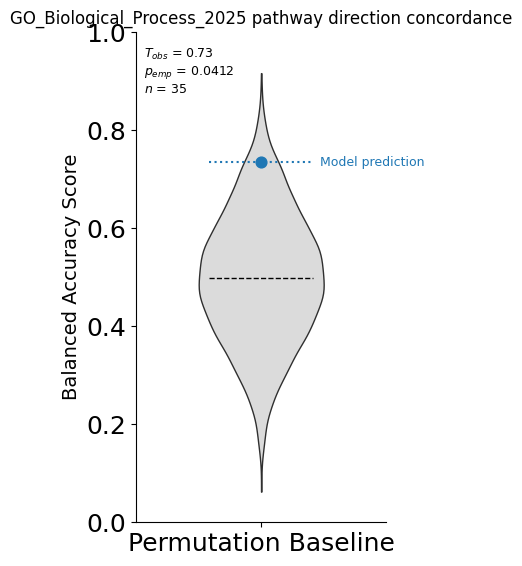

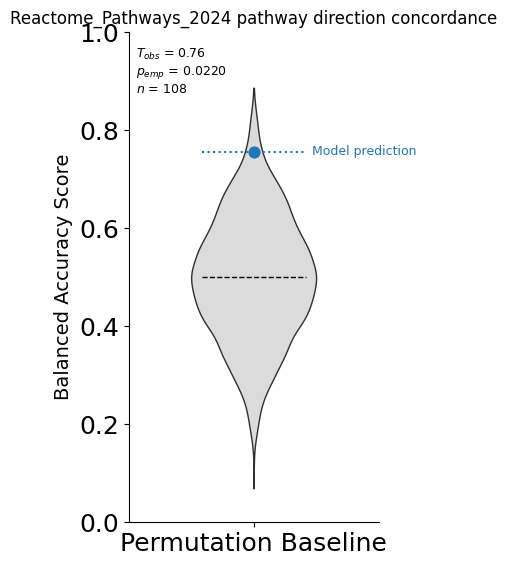

In [ ]:
for name in perm_results:
    r = perm_results[name]
    plot_permutation_violin(
        T_null=r["T_null"],
        T_obs=r["T_obs"],
        p_emp=r["p_emp"],
        n_used=r["n_used"],
        title=f"{name} pathway direction concordance",
    )
    plt.savefig(os.path.join(res_dir, f'{date}_gata1_pathway_violin_dir_concordance_{name.replace(" ", "_")}.pdf'),
                bbox_inches='tight')


In [46]:
gsea_merged_filtered = {}
for name, df in gsea_results.items():
    # filter df for FDR < 0.25 in both
    gsea_merged_filtered[name] = df[df["FDR q-val_real"] < 0.05]
    plot_cmp(gsea_merged_filtered[name], name)

NES_pred  False  True 
NES_real              
False        26      2
True          3      7
Chi2: 12.816940339354133, p-value: 0.00034349499085604783
NES_pred  False  True 
NES_real              
False        55     17
True          2     36
Chi2: 47.58925702344795, p-value: 5.255570265222546e-12


In [47]:
concat_gsea_res = pd.concat(
    [gsea_merged_filtered['GO_Biological_Process_2025'],
     gsea_merged_filtered['Reactome_Pathways_2024'],
     ]
)

In [56]:
def build_sigma_from_full_sets(pathway_genes: dict,
                               universe_genes: set,
                               lam: float = 0.3,
                               min_size: int = 15,
                               max_size: int = 500,
                               variances: dict | None = None):
    """
    pathway_genes: dict {pathway_id: iterable_of_genes} using FULL membership
    universe_genes: set of genes eligible in both analyses
    lam: shrinkage toward identity
    variances: optional dict {pathway_id: variance_of_null_NES}; if None, unit variances

    Returns:
      ids (list), Sigma (ndarray)
    """
    # 1) restrict to universe, apply size filter
    cleaned = {}
    for pid, genes in pathway_genes.items():
        g = set(map(str, genes)) & universe_genes
        if min_size <= len(g) <= max_size:
            cleaned[pid] = g
    ids = sorted(cleaned.keys())
    m = len(ids)


    # 2) cosine similarity matrix
    sizes = np.array([len(cleaned[i]) for i in ids], float)
    S = np.eye(m)
    for i in range(m):
        Ai = cleaned[ids[i]]
        for j in range(i+1, m):
            Aj = cleaned[ids[j]]
            inter = len(Ai & Aj)
            den = (sizes[i]*sizes[j])**0.5 if sizes[i] and sizes[j] else 0.0
            S[i,j] = S[j,i] = (inter/den) if den>0 else 0.0

    # 3) shrinkage to ensure positive definiteness / stability
    R = (1 - lam) * S + lam * np.eye(m)

    # 4) (optional) scale by per-pathway variances
    if variances is None:
        Sigma = R
    else:
        d = np.array([max(variances.get(pid, 1.0), 1e-12) for pid in ids], float)
        Dhalf = np.sqrt(d)
        Sigma = (R * Dhalf).T * Dhalf

    # 5) tiny eigen clip as a safeguard
    w, V = np.linalg.eigh(Sigma)
    w = np.clip(w, 1e-8, None)
    Sigma = (V * w) @ V.T
    return ids, Sigma, S

In [57]:
# concatenate GO and reactome first
combined_pathways = {**go_bio, **reactome_2024}
# filter for significant pathways in concat_gsea_res
combined_pathways = {
    row['Term']: combined_pathways[row['Term']]
    for _, row in concat_gsea_res.iterrows()
    if row['Term'] in combined_pathways
}
universe_genes = set(tf_gata1_ranks.index) & set(gata1_ranks.index)
print(f'Number of universe genes: {len(universe_genes)}')
print(f'Number of pathways: {len(combined_pathways)}')
ids, Sigma, S = build_sigma_from_full_sets(
    combined_pathways, 
    universe_genes,
)

Number of universe genes: 3921
Number of pathways: 148


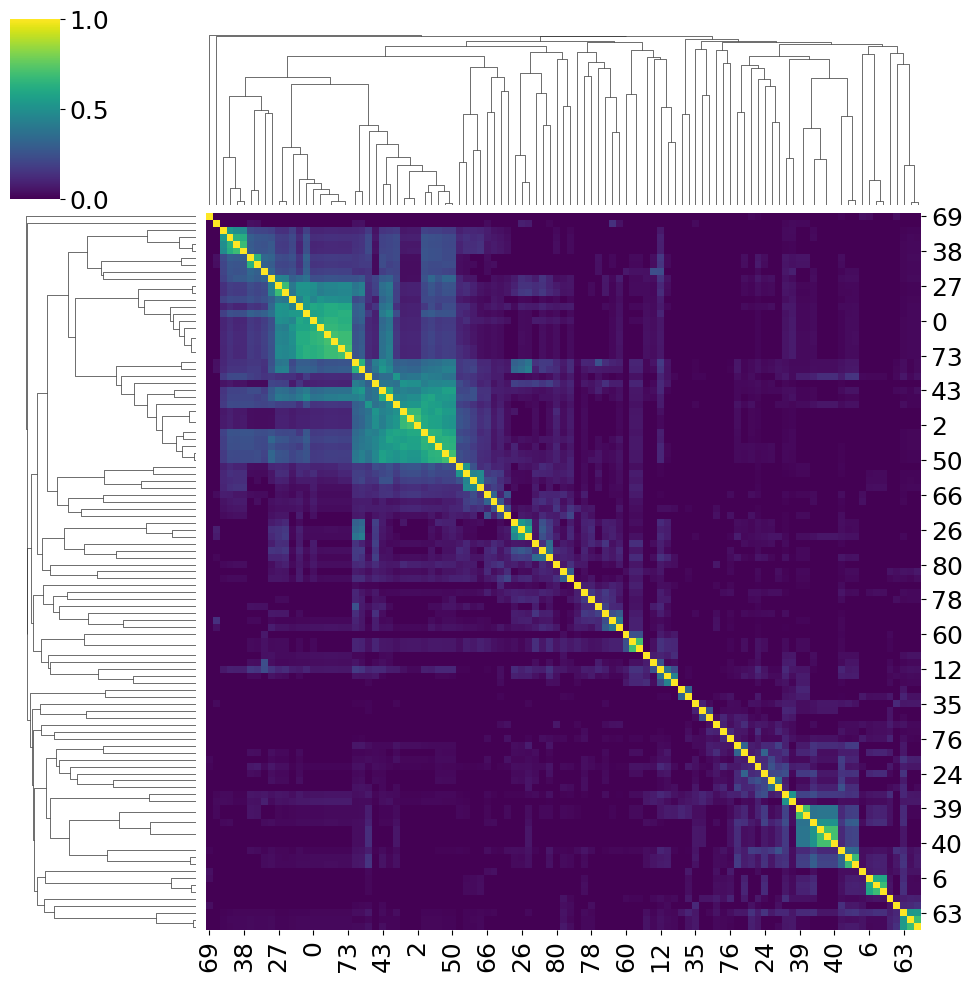

In [58]:
# create a clustermap based on sigma
dist = 1 - S
Z = linkage(squareform(dist), method="average")

clusters = fcluster(Z, t=0.6, criterion="distance")

cluster_map = pd.DataFrame({"Term": ids, "cluster": clusters})
# # print cluster number
# cluster_map['cluster'].value_counts().head(20)
sns.clustermap(Sigma, row_linkage=Z, col_linkage=Z, cmap="viridis")
# save figure
plt.savefig(res_dir + f'GATA1_gsea_pathway_correlation_clustermap.pdf', dpi=300)

In [59]:
concat_gsea_res

,Term,NES_real,FDR q-val_real,Lead_genes_real,NES_pred,FDR q-val_pred,Lead_genes_pred,sign_consistent
0,Mitotic Sister Chromatid Segregation (GO:0000070),-2.133700,0.000000,PRC1;TPX2;BIRC5;DLGAP5;CENPE;KIF15;SMC4;KNL1;S...,-1.211117,0.639718,PRC1;PIBF1;NCAPG;TPX2;KIF11;SMC4;KIF15;KIF14;D...,True
1,Mitotic Spindle Organization (GO:0007052),-2.060793,0.000000,PRC1;TPX2;BIRC5;DLGAP5;CENPE;KIF15;SMC1A;AURKA...,-0.844030,0.990919,PRC1;PIBF1;TPX2;KIF11;DYNC1H1;KIF15;DLGAP5;GPS...,True
2,Positive Regulation of Cell Cycle Process (GO:...,-2.035818,0.000123,BIRC5;SMC4;KNL1;NCAPG;AURKA;KIF20B;NDC80;NUSAP...,-1.370358,0.397360,EREG;E2F8;LEF1;NCAPG;SMC4;DYNC1H1;KIF14;GPSM2;...,True
3,Microtubule Cytoskeleton Organization Involved...,-2.020389,0.000185,BIRC5;DLGAP5;CENPE;NDC80;NUSAP1;KIF11;NUF2;CCN...,0.739287,0.971438,STMN1;FAM110A;SUN2,False
4,Positive Regulation of Leukocyte Mediated Cyto...,2.008784,0.023396,HLA-E;HLA-A;STAP1;SPI1;TYROBP;HLA-B;HLA-C;HLA-...,1.685057,0.032934,SPI1;TYROBP;STX7;HLA-E;HLA-DRA,True
...,...,...,...,...,...,...,...,...
105,Iron Uptake and Transport,-1.602005,0.039574,TFRC;TFR2;ABCG2;ATP6V0A1,-1.585466,0.109362,TFR2;SLC40A1;TFRC;ATP6V0A2,True
106,SUMOylation of Intracellular Receptors,-1.596290,0.042147,THRB;PPARA;RXRA;NR1H2;THRA;NR3C1,-0.994788,0.813574,PPARA;THRA;NR3C1,True
107,Nuclear Receptor Transcription Pathway,-1.592719,0.043622,ESR2;THRB;PPARA;RXRA;NR1H2;THRA;NR3C1;ESRRA;NR2F6,-0.910904,0.907803,PPARA;THRA;NR3C1;NR2F6;NR2C2,True
108,Cellular Response to Heat Stress,-1.586790,0.046119,HSP90AA1;HSPA4L;FKBP4;SERPINH1;HSF1;HSPH1;NUP2...,1.125770,0.471919,MAPKAPK2;EEF1A1;BAG3;SERPINH1;CAMK2D;HSPA8;HSP...,False


In [60]:
# concat_gsea_res
plt.figure(figsize=(16,6))
# add cluster info to concat_gsea_res
term_to_cluster = {term: cluster for term, cluster in zip(cluster_map['Term'], cluster_map['cluster'])}
concat_gsea_res['cluster'] = concat_gsea_res['Term'].map(term_to_cluster)
# only keep clusters with more than 5 members
cluster_counts = concat_gsea_res['cluster'].value_counts()
valid_clusters = cluster_counts[cluster_counts > 3].index
concat_gsea_res['plot_cluster'] = concat_gsea_res['cluster'].where(concat_gsea_res['cluster'].isin(valid_clusters), other='Other')
cluster_naming = {
    '1.0': 'Golgi-to-ER retrograde transport',
    '3.0': 'G2M transition',
    '2.0': 'HCMV-dependent cell cycle reprogramming',
    '38.0': 'Fcγ receptor–driven phagocytosis',
    '4.0': 'Cell cycle',
    '5.0': 'Mitotic Spindle',
}
# create cmap to set 'Other' to gray
cmap = sns.color_palette("tab10", n_colors=len(cluster_naming))
cmap_dict = {name: cmap[i] for i, name in enumerate(cluster_naming.values())}
cmap_dict['Other'] = 'lightgray'
# map clusters
concat_gsea_res['plot_cluster'] = concat_gsea_res['plot_cluster'].astype(str).map(
    lambda x: cluster_naming.get(x, x)
)
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=concat_gsea_res, x="NES_real", y="NES_pred",
    hue="plot_cluster", palette=cmap_dict, s=75,
)
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(0, color="gray", lw=1, ls="--")
# compute chi-square test
chi2, p = chi2_contingency(pd.crosstab(concat_gsea_res["NES_real"]>0, concat_gsea_res["NES_pred"] > 0))[:2]
print(pd.crosstab(concat_gsea_res["NES_real"]>0, concat_gsea_res["NES_pred"] > 0))
print(f"Chi2: {chi2}, p-value: {p}")
plt.text(
    0.95,
    0.15,
    f"Chi2: {chi2:.3f},\np-value: {p:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
plt.legend(bbox_to_anchor=(1.3, 1.05), loc='upper left', title='Cluster')
plt.xlabel("TF NES"); plt.ylabel("In Silico NES")


plt.savefig(f"{res_dir}/GATA1_fdr0.05_NES_scatter_cluster.pdf", dpi=300, bbox_inches="tight")
plt.close()

NES_pred  False  True 
NES_real              
False        81     19
True          5     43
Chi2: 63.5090103775944, p-value: 1.5963497065261866e-15


<Figure size 1600x600 with 0 Axes>

In [61]:
concat_gsea_res[concat_gsea_res['plot_cluster'] == '38.0']

,Term,NES_real,FDR q-val_real,Lead_genes_real,NES_pred,FDR q-val_pred,Lead_genes_pred,sign_consistent,cluster,plot_cluster


In [62]:
# color flipped (incorrect) red, same (correct) green
concat_gsea_res["sign_insilico"] = np.sign(concat_gsea_res["NES_pred"])
concat_gsea_res["sign_tf"]       = np.sign(concat_gsea_res["NES_real"])
concat_gsea_res["flip"]          = concat_gsea_res["sign_insilico"] != concat_gsea_res["sign_tf"]
is_flip = concat_gsea_res["flip"].values.astype(bool)
colors = np.where(is_flip, "#CC3311", "#4C72B0") 

plt.figure(figsize=(6,6))
plt.scatter(concat_gsea_res["NES_real"], concat_gsea_res["NES_pred"], s=30,
            c=colors)
plt.axhline(0, ls="--", lw=1, c="grey")
plt.axvline(0, ls="--", lw=1, c="grey")
# compute chi-square test
chi2, p = chi2_contingency(pd.crosstab(concat_gsea_res["NES_real"]>0, concat_gsea_res["NES_pred"] > 0))[:2]
print(f"Chi2: {chi2}, p-value: {p}")
print(pd.crosstab(concat_gsea_res["NES_real"]>0, concat_gsea_res["NES_pred"] > 0))
plt.text(
    0.95,
    0.15,
    f"Chi2: {chi2:.3f},\np-value: {p:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
plt.xlabel("TF NES"); plt.ylabel("In Silico NES")

# add legend
import matplotlib.patches as mpatches
blue_patch = Line2D([0], [0], marker='o', color='w',
                    markerfacecolor="#4C72B0", markersize=8,
                    label=f"same sign n={int((~is_flip).sum())}",
                    )
red_patch = Line2D([0], [0], marker='o', color='w',
                    markerfacecolor="#CC3311", markersize=8,
                    label=f"flip n={int((is_flip).sum())}")
plt.legend(handles=[blue_patch, red_patch], loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

plt.savefig(f"{res_dir}/GATA1_fdr0.05_NES_scatter.pdf", dpi=300, bbox_inches="tight")
plt.close()

Chi2: 63.5090103775944, p-value: 1.5963497065261866e-15
NES_pred  False  True 
NES_real              
False        81     19
True          5     43


In [63]:

# for name, df in concat_gsea_res.items():
# filter for 
sp = spearmanr(concat_gsea_res["NES_pred"], concat_gsea_res["NES_real"]).statistic
pe = pearsonr(concat_gsea_res["NES_pred"], concat_gsea_res["NES_real"]).statistic
stats = {
    "n_terms": len(concat_gsea_res),
    "spearman": sp,
    "pearson": pe,
    "same_sign_frac": concat_gsea_res["sign_consistent"].mean(),
}


In [64]:
concat_gsea_res

,Term,NES_real,FDR q-val_real,Lead_genes_real,NES_pred,FDR q-val_pred,Lead_genes_pred,sign_consistent,cluster,plot_cluster,sign_insilico,sign_tf,flip
0,Mitotic Sister Chromatid Segregation (GO:0000070),-2.133700,0.000000,PRC1;TPX2;BIRC5;DLGAP5;CENPE;KIF15;SMC4;KNL1;S...,-1.211117,0.639718,PRC1;PIBF1;NCAPG;TPX2;KIF11;SMC4;KIF15;KIF14;D...,True,5.0,Mitotic Spindle,-1.0,-1.0,False
1,Mitotic Spindle Organization (GO:0007052),-2.060793,0.000000,PRC1;TPX2;BIRC5;DLGAP5;CENPE;KIF15;SMC1A;AURKA...,-0.844030,0.990919,PRC1;PIBF1;TPX2;KIF11;DYNC1H1;KIF15;DLGAP5;GPS...,True,5.0,Mitotic Spindle,-1.0,-1.0,False
2,Positive Regulation of Cell Cycle Process (GO:...,-2.035818,0.000123,BIRC5;SMC4;KNL1;NCAPG;AURKA;KIF20B;NDC80;NUSAP...,-1.370358,0.397360,EREG;E2F8;LEF1;NCAPG;SMC4;DYNC1H1;KIF14;GPSM2;...,True,6.0,Other,-1.0,-1.0,False
3,Microtubule Cytoskeleton Organization Involved...,-2.020389,0.000185,BIRC5;DLGAP5;CENPE;NDC80;NUSAP1;KIF11;NUF2;CCN...,0.739287,0.971438,STMN1;FAM110A;SUN2,False,5.0,Mitotic Spindle,1.0,-1.0,True
4,Positive Regulation of Leukocyte Mediated Cyto...,2.008784,0.023396,HLA-E;HLA-A;STAP1;SPI1;TYROBP;HLA-B;HLA-C;HLA-...,1.685057,0.032934,SPI1;TYROBP;STX7;HLA-E;HLA-DRA,True,27.0,Other,1.0,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Iron Uptake and Transport,-1.602005,0.039574,TFRC;TFR2;ABCG2;ATP6V0A1,-1.585466,0.109362,TFR2;SLC40A1;TFRC;ATP6V0A2,True,NaN,Other,-1.0,-1.0,False
106,SUMOylation of Intracellular Receptors,-1.596290,0.042147,THRB;PPARA;RXRA;NR1H2;THRA;NR3C1,-0.994788,0.813574,PPARA;THRA;NR3C1,True,NaN,Other,-1.0,-1.0,False
107,Nuclear Receptor Transcription Pathway,-1.592719,0.043622,ESR2;THRB;PPARA;RXRA;NR1H2;THRA;NR3C1;ESRRA;NR2F6,-0.910904,0.907803,PPARA;THRA;NR3C1;NR2F6;NR2C2,True,21.0,Other,-1.0,-1.0,False
108,Cellular Response to Heat Stress,-1.586790,0.046119,HSP90AA1;HSPA4L;FKBP4;SERPINH1;HSF1;HSPH1;NUP2...,1.125770,0.471919,MAPKAPK2;EEF1A1;BAG3;SERPINH1;CAMK2D;HSPA8;HSP...,False,23.0,Other,1.0,-1.0,True


In [65]:
# concat_gsea_res = merged NES table with: Term, NES_pred, NES_real, Size, Size_tf, NES_pred, FDR_real

# 1) Sign agreement & quadrant counts
concat_gsea_res["same_sign"] = (concat_gsea_res.NES_pred * concat_gsea_res.NES_real) > 0
quad = {
    "up/up":  ((concat_gsea_res.NES_pred>0) & (concat_gsea_res.NES_real>0)).mean(),
    "down/down": ((concat_gsea_res.NES_pred<0) & (concat_gsea_res.NES_real<0)).mean(),
    "flip A up B down": ((concat_gsea_res.NES_pred>0) & (concat_gsea_res.NES_real<0)).mean(),
    "flip A down B up": ((concat_gsea_res.NES_pred<0) & (concat_gsea_res.NES_real>0)).mean(),
}

# 2) NES distribution shift (scale/location)
import numpy as np
mu_a, sd_a = concat_gsea_res.NES_pred.mean(), concat_gsea_res.NES_pred.std()
mu_b, sd_b = concat_gsea_res.NES_real.mean(), concat_gsea_res.NES_real.std()

# 3) Bland–Altman style bias: mean vs difference
concat_gsea_res["meanNES"] = 0.5*(concat_gsea_res.NES_pred + concat_gsea_res.NES_real)
concat_gsea_res["diffNES"] = concat_gsea_res.NES_pred - concat_gsea_res.NES_real
bias = concat_gsea_res["diffNES"].mean()

# 4) Size effects: residuals vs set size
import statsmodels.api as sm
X = sm.add_constant(concat_gsea_res[["NES_pred"]])
beta = sm.OLS(concat_gsea_res["NES_real"], X).fit()
concat_gsea_res["resid"] = concat_gsea_res["NES_real"] - beta.predict(X)

# # correlation of residuals with size (if positive, larger sets skew)
# res_size_corr = concat_gsea_res[["resid","Size"]].corr().iloc[0,1]

# 5) Significant-only sensitivities (not for the main result, just diagnostic)
mask_both_sig = (concat_gsea_res['FDR q-val_pred'] < 0.1) & (concat_gsea_res['FDR q-val_real'] < 0.1)
mask_either   = (concat_gsea_res['FDR q-val_pred'] < 0.1) | (concat_gsea_res['FDR q-val_real'] < 0.1)
print(f"{name}: {mask_both_sig.sum()} terms significant in both, {mask_either.sum()} in either")
print(f"""
Sign agreement: {concat_gsea_res['same_sign'].mean():.2f} (up/up {quad['up/up']:.2f}, down/down {quad['down/down']:.2f}, flip {quad['flip A up B down']+quad['flip A down B up']:.2f})
NES mean/sd: insilico {mu_a:.2f}/{sd_a:.2f}, TF {mu_b:.2f}/{sd_b:.2f}
Bland-Altman bias (mean diff): {bias:.2f}
""")


Reactome_Pathways_2024: 14 terms significant in both, 148 in either

Sign agreement: 0.84 (up/up 0.29, down/down 0.55, flip 0.16)
NES mean/sd: insilico -0.12/1.19, TF -0.63/1.74
Bland-Altman bias (mean diff): 0.51



In [66]:
# sort audit by NFS_tf descending
concat_gsea_res.sort_values('NES_real', ascending=False)

,Term,NES_real,FDR q-val_real,Lead_genes_real,NES_pred,FDR q-val_pred,Lead_genes_pred,sign_consistent,cluster,plot_cluster,sign_insilico,sign_tf,flip,same_sign,meanNES,diffNES,resid
17,Leishmania Phagocytosis,2.066561,0.001445,ELMO1;VAV3;ACTG1;LYN;MYO5A,1.320161,0.246965,ACTG1;CYFIP2;BAIAP2;FCGR3A,True,38.0,Fcγ receptor–driven phagocytosis,1.0,1.0,False,True,1.693361,-0.746400,1.199617
15,FCGR3A-mediated Phagocytosis,2.066561,0.001445,ELMO1;VAV3;ACTG1;LYN;MYO5A,1.320161,0.246965,ACTG1;CYFIP2;BAIAP2;FCGR3A,True,38.0,Fcγ receptor–driven phagocytosis,1.0,1.0,False,True,1.693361,-0.746400,1.199617
16,Parasite Infection,2.066561,0.001445,ELMO1;VAV3;ACTG1;LYN;MYO5A,1.320161,0.246965,ACTG1;CYFIP2;BAIAP2;FCGR3A,True,38.0,Fcγ receptor–driven phagocytosis,1.0,1.0,False,True,1.693361,-0.746400,1.199617
18,Innate Immune System,2.058472,0.001239,PTPRC;ELMO1;VAV3;GAB2;ACTG1;P2RX1;CD55;CD63;LY...,2.016085,0.000000,ACTG1;FCER1G;CTSB;CYBB;LAIR1;ISG15;CTSS;CTSZ;C...,True,37.0,Other,1.0,1.0,False,True,2.037279,-0.042387,0.465792
4,Positive Regulation of Leukocyte Mediated Cyto...,2.008784,0.023396,HLA-E;HLA-A;STAP1;SPI1;TYROBP;HLA-B;HLA-C;HLA-...,1.685057,0.032934,SPI1;TYROBP;STX7;HLA-E;HLA-DRA,True,27.0,Other,1.0,1.0,False,True,1.846921,-0.323728,0.761313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,Cell Cycle Checkpoints,-2.331150,0.000000,CENPF;BIRC5;CENPE;ORC6;UBE2S;MCM4;CCNB2;CDKN2A...,-1.039339,0.798481,MCM4;BRCA1;NDE1;BUB1;DYNC1H1;MCM7;AHCTF1;CLIP1...,True,4.0,Cell cycle,-1.0,-1.0,False,True,-1.685245,1.291811,-0.737521
3,Mitotic Metaphase and Anaphase,-2.341253,0.000000,CENPF;BIRC5;CENPE;TMPO;UBE2S;CCNB2;TUBA1B;LMNA...,-1.027439,0.786287,LMNA;TMPO;NDE1;BUB1;DYNC1H1;AHCTF1;CLIP1;CENPM...,True,4.0,Cell cycle,-1.0,-1.0,False,True,-1.684346,1.313814,-0.760033
2,M Phase,-2.354571,0.000000,CENPF;PRKAR2B;BIRC5;CENPE;TMPO;UBE2S;SMC4;CCNB...,-1.036190,0.789378,PRKAR2B;LMNA;HIST1H3G;TMPO;NCAPG;NDE1;BUB1;SMC...,True,4.0,Cell cycle,-1.0,-1.0,False,True,-1.695381,1.318381,-0.764226
1,Cell Cycle,-2.375176,0.000000,CENPF;TPX2;MYBL2;PRKAR2B;BIRC5;CENPE;TMPO;DHFR...,-1.035610,0.785527,MYC;PRKAR2B;LMNA;MCM4;E2F3;TFDP2;HIST1H3G;E2F4...,True,4.0,Cell cycle,-1.0,-1.0,False,True,-1.705393,1.339566,-0.785436


In [67]:
# sort audit by NFS_tf descending
concat_gsea_res.sort_values('NES_real', ascending=True)

,Term,NES_real,FDR q-val_real,Lead_genes_real,NES_pred,FDR q-val_pred,Lead_genes_pred,sign_consistent,cluster,plot_cluster,sign_insilico,sign_tf,flip,same_sign,meanNES,diffNES,resid
0,"Cell Cycle, Mitotic",-2.420221,0.000000,CENPF;TPX2;MYBL2;PRKAR2B;BIRC5;CENPE;TMPO;DHFR...,-0.993020,0.815416,MYC;PRKAR2B;LMNA;MCM4;E2F3;TFDP2;HIST1H3G;E2F4...,True,4.0,Cell cycle,-1.0,-1.0,False,True,-1.706621,1.427201,-0.874895
1,Cell Cycle,-2.375176,0.000000,CENPF;TPX2;MYBL2;PRKAR2B;BIRC5;CENPE;TMPO;DHFR...,-1.035610,0.785527,MYC;PRKAR2B;LMNA;MCM4;E2F3;TFDP2;HIST1H3G;E2F4...,True,4.0,Cell cycle,-1.0,-1.0,False,True,-1.705393,1.339566,-0.785436
2,M Phase,-2.354571,0.000000,CENPF;PRKAR2B;BIRC5;CENPE;TMPO;UBE2S;SMC4;CCNB...,-1.036190,0.789378,PRKAR2B;LMNA;HIST1H3G;TMPO;NCAPG;NDE1;BUB1;SMC...,True,4.0,Cell cycle,-1.0,-1.0,False,True,-1.695381,1.318381,-0.764226
3,Mitotic Metaphase and Anaphase,-2.341253,0.000000,CENPF;BIRC5;CENPE;TMPO;UBE2S;CCNB2;TUBA1B;LMNA...,-1.027439,0.786287,LMNA;TMPO;NDE1;BUB1;DYNC1H1;AHCTF1;CLIP1;CENPM...,True,4.0,Cell cycle,-1.0,-1.0,False,True,-1.684346,1.313814,-0.760033
4,Cell Cycle Checkpoints,-2.331150,0.000000,CENPF;BIRC5;CENPE;ORC6;UBE2S;MCM4;CCNB2;CDKN2A...,-1.039339,0.798481,MCM4;BRCA1;NDE1;BUB1;DYNC1H1;MCM7;AHCTF1;CLIP1...,True,4.0,Cell cycle,-1.0,-1.0,False,True,-1.685245,1.291811,-0.737521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,Positive Regulation of Leukocyte Mediated Cyto...,2.008784,0.023396,HLA-E;HLA-A;STAP1;SPI1;TYROBP;HLA-B;HLA-C;HLA-...,1.685057,0.032934,SPI1;TYROBP;STX7;HLA-E;HLA-DRA,True,27.0,Other,1.0,1.0,False,True,1.846921,-0.323728,0.761313
18,Innate Immune System,2.058472,0.001239,PTPRC;ELMO1;VAV3;GAB2;ACTG1;P2RX1;CD55;CD63;LY...,2.016085,0.000000,ACTG1;FCER1G;CTSB;CYBB;LAIR1;ISG15;CTSS;CTSZ;C...,True,37.0,Other,1.0,1.0,False,True,2.037279,-0.042387,0.465792
15,FCGR3A-mediated Phagocytosis,2.066561,0.001445,ELMO1;VAV3;ACTG1;LYN;MYO5A,1.320161,0.246965,ACTG1;CYFIP2;BAIAP2;FCGR3A,True,38.0,Fcγ receptor–driven phagocytosis,1.0,1.0,False,True,1.693361,-0.746400,1.199617
16,Parasite Infection,2.066561,0.001445,ELMO1;VAV3;ACTG1;LYN;MYO5A,1.320161,0.246965,ACTG1;CYFIP2;BAIAP2;FCGR3A,True,38.0,Fcγ receptor–driven phagocytosis,1.0,1.0,False,True,1.693361,-0.746400,1.199617


In [68]:
# choose top 30 pathways by absolute NES in TF data
upr_pathways = (concat_gsea_res
    .assign(abs_NES_real = concat_gsea_res['NES_real'])
    .sort_values('abs_NES_real', ascending=False)
    .head(30)
    ['Term']
    .tolist()
)
concat_gsea_res_upr = concat_gsea_res[concat_gsea_res['Term'].isin(upr_pathways)]
downr_pathways = (concat_gsea_res
    .assign(abs_NES_real = concat_gsea_res['NES_real'])
    .sort_values('abs_NES_real', ascending=True)
    .head(30)
    ['Term']
    .tolist()
)
concat_gsea_res_downr = concat_gsea_res[concat_gsea_res['Term'].isin(downr_pathways)]

In [69]:
concat_gsea_res_upr

,Term,NES_real,FDR q-val_real,Lead_genes_real,NES_pred,FDR q-val_pred,Lead_genes_pred,sign_consistent,cluster,plot_cluster,sign_insilico,sign_tf,flip,same_sign,meanNES,diffNES,resid
4,Positive Regulation of Leukocyte Mediated Cyto...,2.008784,0.023396,HLA-E;HLA-A;STAP1;SPI1;TYROBP;HLA-B;HLA-C;HLA-...,1.685057,0.032934,SPI1;TYROBP;STX7;HLA-E;HLA-DRA,True,27.0,Other,1.0,1.0,False,True,1.846921,-0.323728,0.761313
5,Release of Sequestered Calcium Ion Into Cytoso...,2.004601,0.011698,PTPRC;PLCL2;RYR3;ITPR1;PLCL1;PLCB1;FLNA,-0.853262,1.000000,RYR3;GP1BB;F2R;PLCB4,False,40.0,Other,-1.0,1.0,True,False,0.575670,-2.857863,3.404182
6,Negative Regulation of Sequestering of Calcium...,1.983997,0.015125,PTPRC;PLCL2;RYR3;ITPR1;PLCL1;PLCB1;FLNA,-0.847769,0.995090,RYR3;GP1BB;F2R;PLCB4,False,40.0,Other,-1.0,1.0,True,False,0.568114,-2.831766,3.377850
7,Calcium Ion Transmembrane Import Into Cytosol ...,1.957048,0.019142,PTPRC;PLCL2;RYR3;ITPR1;PLCL1;PLCB1;FLNA,-0.827226,0.983662,RYR3;GP1BB;F2R;PLCB4,False,40.0,Other,-1.0,1.0,True,False,0.564911,-2.784274,3.329477
8,Myeloid Leukocyte Differentiation (GO:0002573),1.927538,0.031053,RUNX1;GAB2;TGFBR2;IL1RL1;CFLAR;FOXP1;SPI1;KIT;...,1.181453,0.403582,SPI1;GPR183;TYROBP;CFLAR;GAB2;MT1G;FOXP1;CD4;I...,True,29.0,Other,1.0,1.0,False,True,1.554496,-0.746085,1.205243
9,Integrin-Mediated Signaling Pathway (GO:0007229),1.921098,0.030131,PLEK;FYB1;TEC;NEDD9;ITGA5;ITGAX;ITGAL;ITGA2B;I...,1.312124,0.261786,ISG15;PLEK;CCM2;FERMT3;FYB1;DAB2;NEDD9;ITGB7;I...,True,28.0,Other,1.0,1.0,False,True,1.616611,-0.608974,1.062535
11,T Cell Differentiation (GO:0030217),1.894539,0.040006,PTPRC;ANXA1;PTPN22;RHOH;SOX4;TGFB1;SPI1;KIT;PI...,0.780186,0.960350,FCER1G;SPI1;PTPRC;CHD7;CD4,True,31.0,Other,1.0,1.0,False,True,1.337362,-1.114353,1.590700
12,Regulation of Wound Healing (GO:0061041),1.885277,0.042627,ANXA1;CASK;ALOX5;PRKCE,0.718023,0.976535,CASK;TNFAIP3;ALOX5,True,41.0,Other,1.0,1.0,False,True,1.301650,-1.167253,1.646264
13,Regulation of Cytokine Production (GO:0001817),1.877163,0.044665,PTPRC;SRGN;ANXA1;ZBTB20;LYN;PLD3;PLAGL1;FOXP1;...,1.000000,0.669579,ISG15;MAPKAPK2;IGF2BP3;LITAF;PTPRC;IRF7;ATP2B1...,True,30.0,Other,1.0,1.0,False,True,1.438581,-0.877163,1.344094
14,Regulation of Tumor Necrosis Factor Production...,1.874061,0.042538,PTPRC;PTPN22;HLA-E;THBS1;FOXP1;CLU;TGFB1;STAT3...,1.858659,0.012404,MAPKAPK2;TYROBP;VSIR;LY96;PTPRC;HLA-E;HAVCR2;T...,True,44.0,Other,1.0,1.0,False,True,1.866360,-0.015402,0.445551


In [72]:
concat_gsea_res_downr = concat_gsea_res[concat_gsea_res['Term'].isin(downr_pathways)]

In [75]:
p_zip = pooch.retrieve(
    "https://www.dropbox.com/s/3dby3bjsaf5arrw/cell_cycle_vignette_files.zip?dl=1",
    known_hash="sha256:6557fe2a2761d1550d41edf61b26c6d5ec9b42b4933d56c3161164a595f145ab",
    path="../data",
)
with zipfile.ZipFile(p_zip, "r") as f_zip:
    cell_cycle_genes = zipfile.Path(f_zip, "regev_lab_cell_cycle_genes.txt").read_text().splitlines()
s_genes = [x for x in cell_cycle_genes[:43] if x in tf_filtered.var_names]
g2m_genes = [x for x in cell_cycle_genes[43:] if x in tf_filtered.var_names]
cell_cycle_genes = [*s_genes, *g2m_genes]
# score cycling cells in healthy
sc.tl.score_genes_cell_cycle(tf_filtered, s_genes=s_genes, g2m_genes=g2m_genes)
sc.tl.score_genes_cell_cycle(adata_gata1, s_genes=s_genes, g2m_genes=g2m_genes)

In [76]:
adata_gata1.obs.status.unique()

['perturbed', 'predicted']
Categories (2, object): ['perturbed', 'predicted']

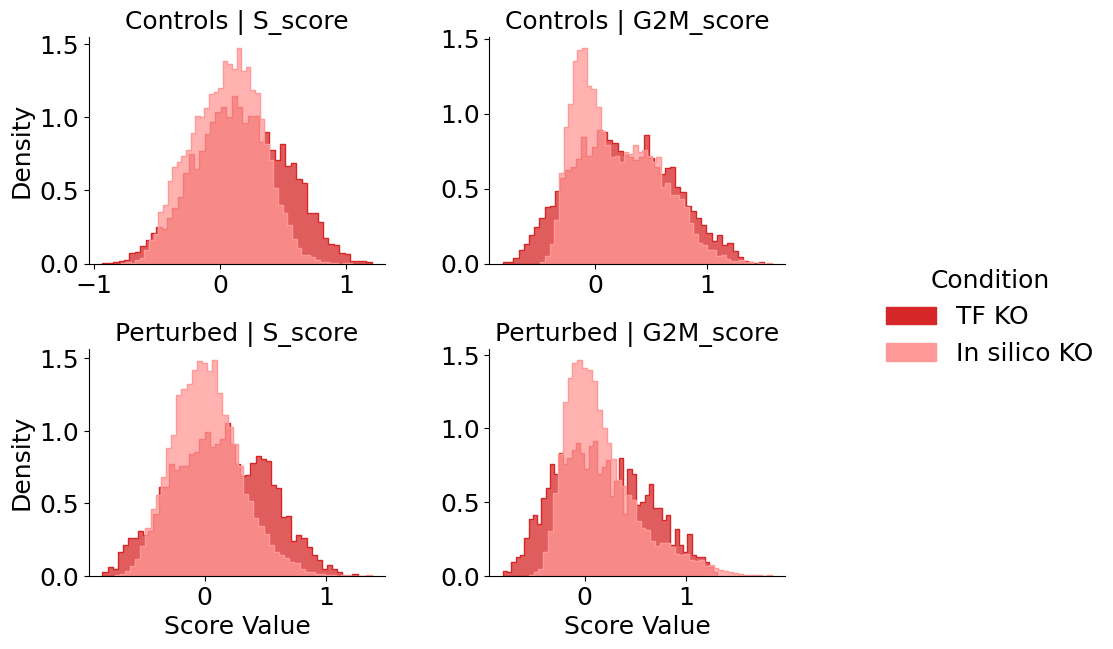

In [77]:
# Subset data
tf_data_ctrl = tf_filtered[tf_filtered.obs['target'] == 'NT'].copy()
tf_data_pat  = tf_filtered[tf_filtered.obs['target'] == 'GATA1'].copy()
adata_gata1_predicted = adata_gata1[adata_gata1.obs['status'] == 'predicted'].copy()
adata_gata1_pert = adata_gata1[adata_gata1.obs['status'] == 'perturbed'].copy()

# Combine all into one dataframe
plot_df = pd.DataFrame({
    'S_score': np.concatenate([
        tf_data_ctrl.obs['S_score'].values,
        tf_data_pat.obs['S_score'].values,
        adata_gata1_predicted.obs['S_score'].values,
        adata_gata1_pert.obs['S_score'].values
    ]),
    'G2M_score': np.concatenate([
        tf_data_ctrl.obs['G2M_score'].values,
        tf_data_pat.obs['G2M_score'].values,
        adata_gata1_predicted.obs['G2M_score'].values,
        adata_gata1_pert.obs['G2M_score'].values
    ]),
    'group': (
        ['NT'] * tf_data_ctrl.shape[0] +
        ['GATA1'] * tf_data_pat.shape[0] +
        ['predicted'] * adata_gata1_predicted.shape[0] +
        ['perturbed'] * adata_gata1_pert.shape[0]
    )
})

# Define facet rows
plot_df['row'] = plot_df['group'].map({
    'NT': 'Controls',
    'predicted': 'Controls',
    'GATA1': 'Perturbed',
    'perturbed': 'Perturbed'
})

# Melt for long format (so we can facet by score)
plot_df_long = plot_df.melt(
    id_vars=['group', 'row'],
    value_vars=['S_score', 'G2M_score'],
    var_name='score_type',
    value_name='score_value'
)

palette = {
    'NT': '#d62728',   # blue
    'GATA1': '#d62728',   # same blue
    'predicted': '#ff9896',  # orange
    'perturbed': '#ff9896'   # same orange
}

# Create FacetGrid: 2 rows (ETV6, Pert) × 2 cols (S_score, G2M_score)
g = sns.FacetGrid(
    plot_df_long,
    row='row',
    col='score_type',
    hue='group',
    palette=palette,
    sharex=False,
    sharey=False,
    height=3.5,
    aspect=1.2,
)

# Map histograms
g.map_dataframe(
    sns.histplot,
    x='score_value',
    element='step',
    stat='density',
    common_norm=False,
    bins=50
)

# Beautify
g.add_legend(title='Group')
g._legend.remove()  # or g.add_legend = lambda *args, **kwargs: None

# 🧩 Create custom legend patches
custom_handles = [
    mpatches.Patch(color='#d62728', label='TF KO'),
    mpatches.Patch(color='#ff9896', label='In silico KO')
]

# 🖼️ Add your custom legend to the figure
g.fig.legend(
    handles=custom_handles,
    title='Condition',
    loc='center right',       # you can use 'upper right', 'lower right', etc.
    bbox_to_anchor=(1.1, 0.5),  # position outside the grid
    frameon=False
)
g.set_axis_labels("Score Value", "Density")
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.fig.subplots_adjust(top=0.9)
# g.fig.suptitle('Cell Cycle Score Distributions across ETV6 and perturbed Conditions')
plt.savefig(
    f'{res_dir}/gata1_cell_cycle_score_invitro_insilico_distributions.pdf',
    dpi=300,
    bbox_inches='tight'
)

In [78]:
plot_df_long

,group,row,score_type,score_value
0,NT,Controls,S_score,0.641851
1,NT,Controls,S_score,0.075315
2,NT,Controls,S_score,0.005153
3,NT,Controls,S_score,-0.055524
4,NT,Controls,S_score,0.631820
...,...,...,...,...
58675,perturbed,Perturbed,G2M_score,0.178212
58676,perturbed,Perturbed,G2M_score,-0.396489
58677,perturbed,Perturbed,G2M_score,-0.279268
58678,perturbed,Perturbed,G2M_score,-0.305235


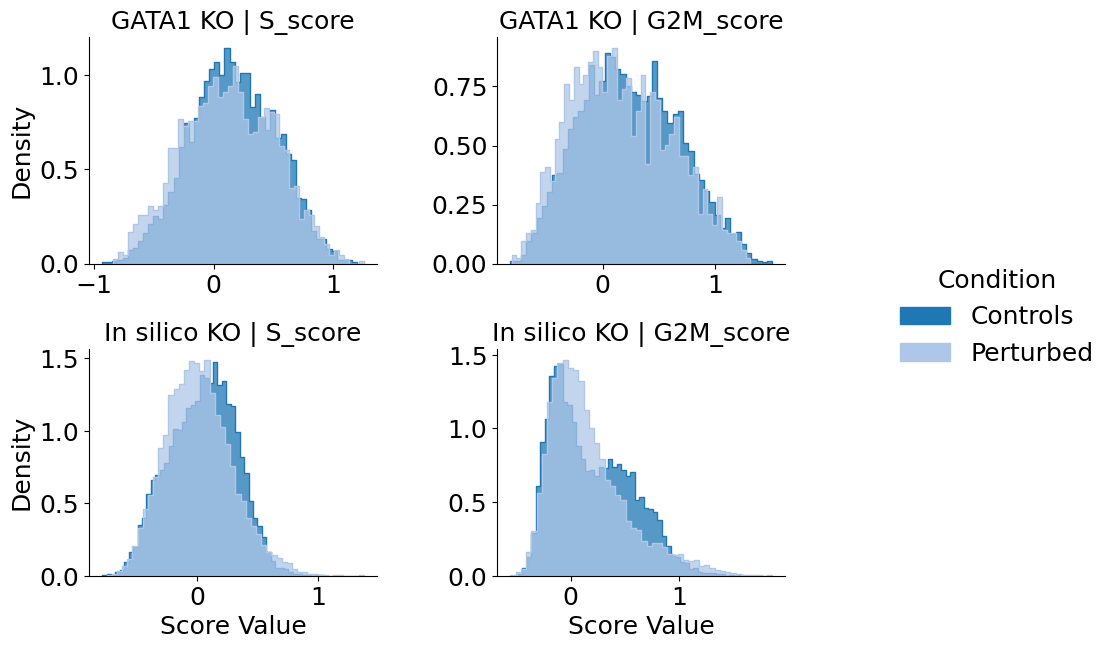

In [79]:
# Define facet rows
plot_df['row'] = plot_df['group'].map({
    'NT': 'GATA1 KO',
    'predicted': 'In silico KO',
    'GATA1': 'GATA1 KO',
    'perturbed': 'In silico KO'
})

# Melt for long format (so we can facet by score)
plot_df_long = plot_df.melt(
    id_vars=['group', 'row'],
    value_vars=['S_score', 'G2M_score'],
    var_name='score_type',
    value_name='score_value'
)

palette = {
    'NT': '#1f77b4',   # blue
    'GATA1': '#aec7e8',   # same blue
    'predicted': '#1f77b4',  # orange
    'perturbed': '#aec7e8'   # same orange
}

# Create FacetGrid: 2 rows (ETV6, Pert) × 2 cols (S_score, G2M_score)
g = sns.FacetGrid(
    plot_df_long,
    row='row',
    col='score_type',
    hue='group',
    palette=palette,
    sharex=False,
    sharey=False,
    height=3.5,
    aspect=1.2,
)

# Map histograms
g.map_dataframe(
    sns.histplot,
    x='score_value',
    element='step',
    stat='density',
    common_norm=False,
    bins=50
)

# Beautify
g.add_legend(title='Group')
g._legend.remove()  # or g.add_legend = lambda *args, **kwargs: None

# 🧩 Create custom legend patches
custom_handles = [
    mpatches.Patch(color='#1f77b4', label='Controls'),
    mpatches.Patch(color='#aec7e8', label='Perturbed')
]

# 🖼️ Add your custom legend to the figure
g.fig.legend(
    handles=custom_handles,
    title='Condition',
    loc='center right',       # you can use 'upper right', 'lower right', etc.
    bbox_to_anchor=(1.1, 0.5),  # position outside the grid
    frameon=False
)
g.set_axis_labels("Score Value", "Density")
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.fig.subplots_adjust(top=0.9)
# g.fig.suptitle('Cell Cycle Score Distributions across ETV6 and Perturb Conditions')

plt.savefig(
    f'{res_dir}/gata1_cell_cycle_score_control_perturbed_distributions.pdf',
    dpi=300,
    bbox_inches='tight'
)

In [80]:
def intersect_lead_genes(concat_gsea_res, term: str):
    # lead genes for this term from both analyses
    all_lead_genes = []

    le_genes = concat_gsea_res[concat_gsea_res['Term'] == term]['Lead_genes_real']
    if not le_genes.empty:
        genes = le_genes.values[0].split(';')
        all_lead_genes.extend(genes)
    # le_genes = concat_gsea_res[concat_gsea_res['Term'] == term]['Lead_genes_insilico']
    # if not le_genes.empty:
    #     genes = le_genes.values[0].split(';')
    #     all_lead_genes.extend(genes)
    all_lead_genes = list(set(all_lead_genes))
    return all_lead_genes

In [81]:


def plot_lead_gene_directionality(degs_pert, degs_gata1, concat_gsea_res, term):
    # save under gsea_plots
    gsea_res_dir = Path(res_dir) / 'gsea_plots'
    os.makedirs(gsea_res_dir, exist_ok=True)
    all_lead_genes = intersect_lead_genes(concat_gsea_res, term)
    # print(f'Number of lead genes for term {term}: {len(all_lead_genes)}')
    # subset the deg tables
    in_silico_ranks_ = degs_pert[degs_pert['names'].isin(all_lead_genes)]
    gata1_ko_ranks_ = degs_gata1[degs_gata1['names'].isin(all_lead_genes)]

    # align on the same gene order (use gata1 order)
    gata1_ko_ranks_ = gata1_ko_ranks_[gata1_ko_ranks_['names'].isin(in_silico_ranks_['names'])]
    order = in_silico_ranks_['names'].tolist()

    tf_aligned   = (gata1_ko_ranks_.drop_duplicates('names')
                    .set_index('names').reindex(order).dropna().reset_index())
    in_silico_aligned = (in_silico_ranks_.drop_duplicates('names')
                    .set_index('names').reindex(order).dropna().reset_index())


    merged_aligned = tf_aligned.merge(in_silico_aligned, on="names", suffixes=("_tf", "_gata1"))
    # sort by logFC_tf (largest first)
    merged_aligned = merged_aligned.sort_values("logfoldchanges_tf", ascending=False)

    X = np.concatenate([
        merged_aligned['logfoldchanges_tf'].values[:, None],
        merged_aligned['logfoldchanges_gata1'].values[:, None],
    ], axis=1)
    adata_genes = sc.AnnData(X=X.T)
    adata_genes.var_names = merged_aligned[['names']].values.flatten()
    adata_genes.obs = pd.DataFrame({
        'method': ['In Vitro', 'In Silico']
    })

    adata_genes.var_names = merged_aligned[['names']].values.flatten()
    adata_genes.obs = pd.DataFrame({
        'method': ['In Vitro', 'In Silico']
    })


    # replace X so that it is 1 for positive logFC and -1 for negative logFC
    adata_genes.X = np.where(adata_genes.X > 0, 1, -1)
    # define extreme colors: negative -> red, zero -> white, positive -> blue
    cmap = mpl.colors.LinearSegmentedColormap.from_list(
        "posneg_extremes", ["#8ab4e0", "#FFFFFF", "#ed6677"]
    )
    norm = mpl.colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    sc.pl.dotplot(
        adata_genes,
        var_names=sorted(adata_genes.var_names),
        groupby='method',
        swap_axes=False,
        cmap=cmap,
        # norm=norm,
        vmin=-1, vmax=1,
        mean_only_expressed=False,
        expression_cutoff=-np.inf,
        show=False,
        # figsize=(2.35, 10)
    )
    # replace special character for term to save
    term_safe = term.replace("/", "_").replace(" ", "_").replace("(", "").replace(")", "")
    # save figure
    plt.savefig(f"{gsea_res_dir}/Directionality_dotplot_{term_safe}.pdf", dpi=300, bbox_inches="tight")

/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/scanpy/plotting/_utils.py:1241: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=ax_or_figsize)


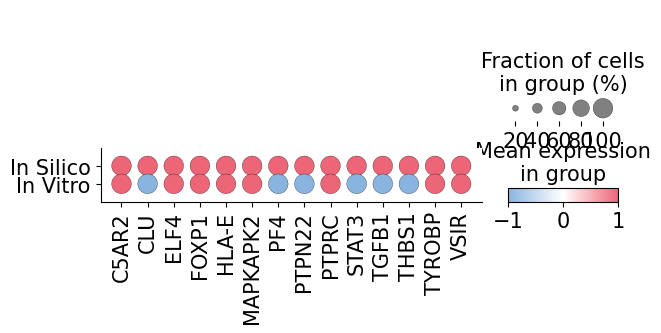

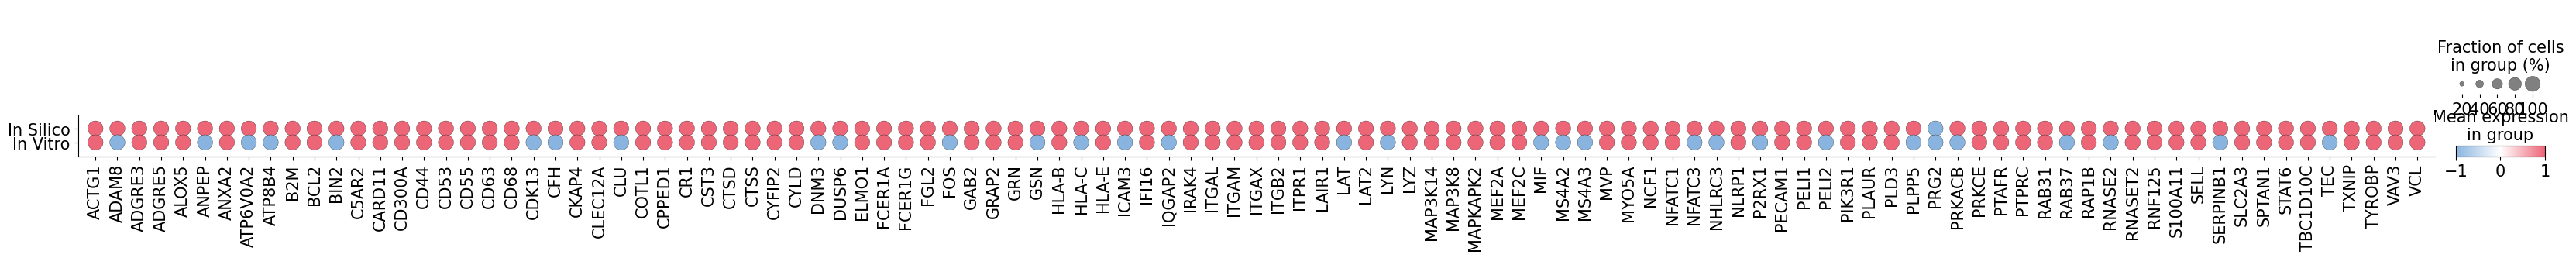

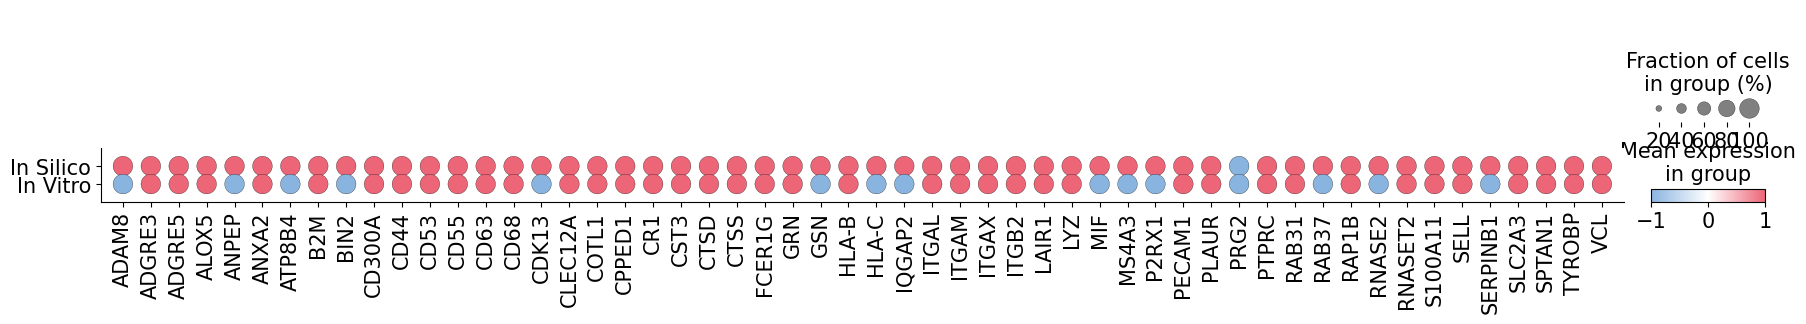

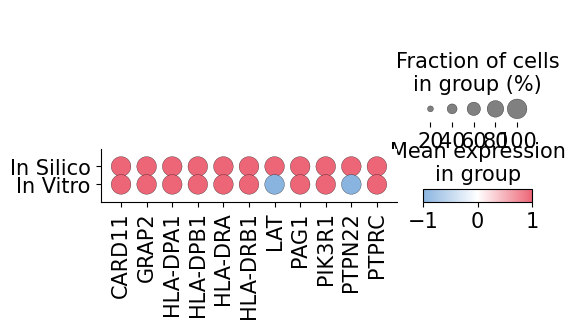

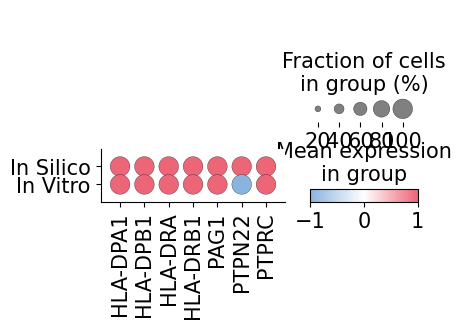

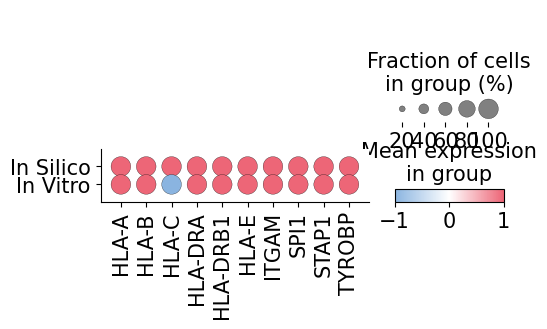

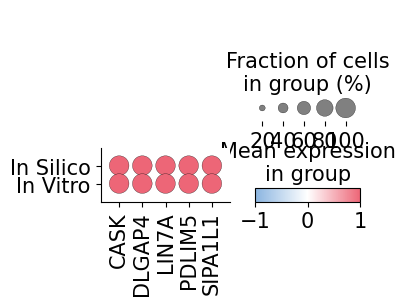

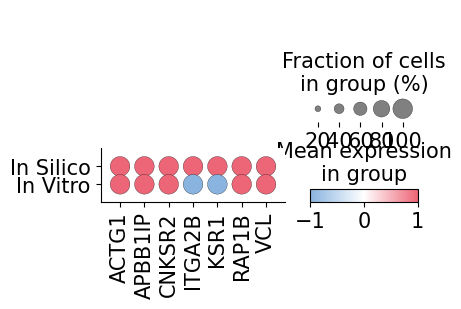

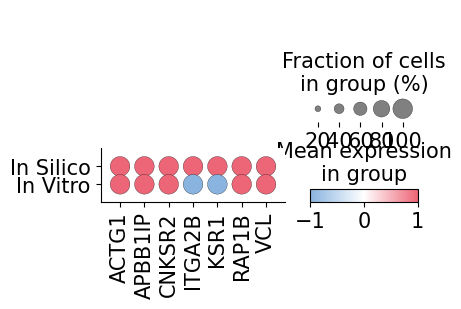

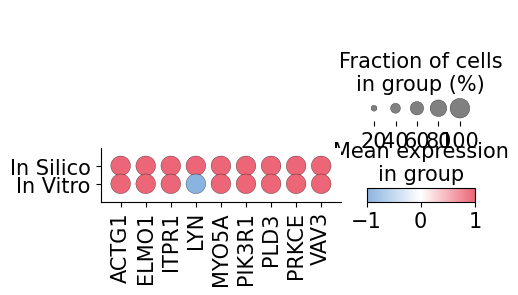

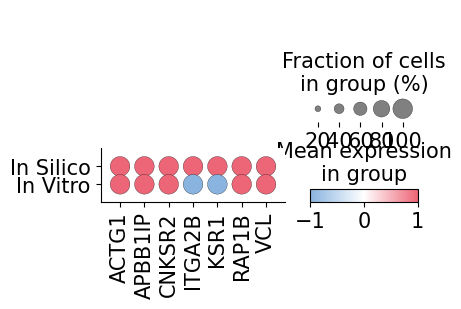

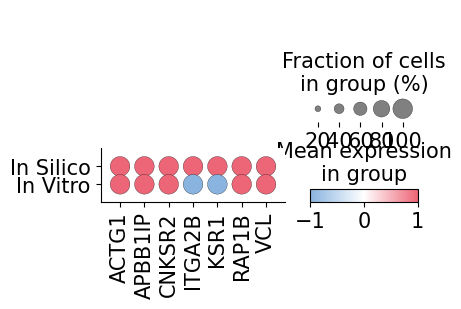

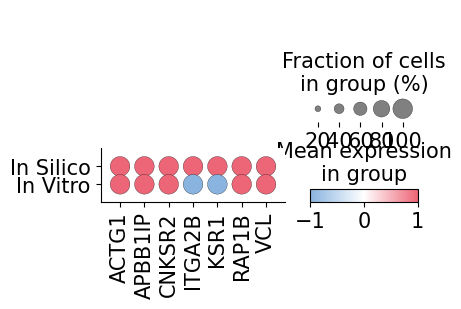

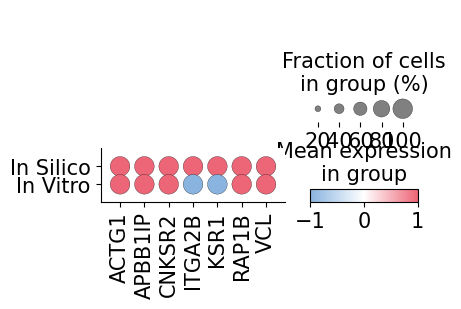

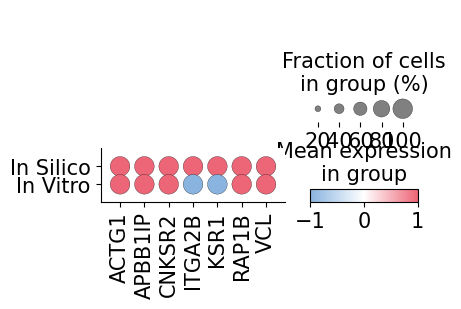

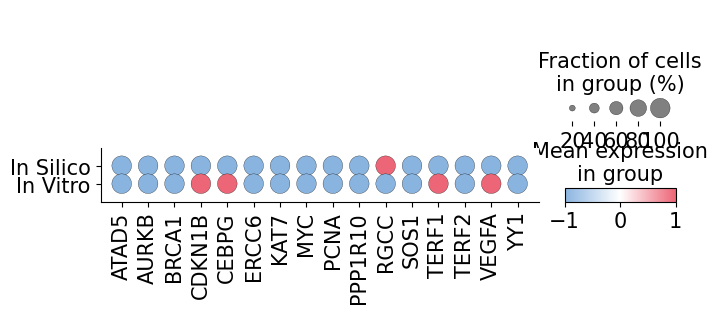

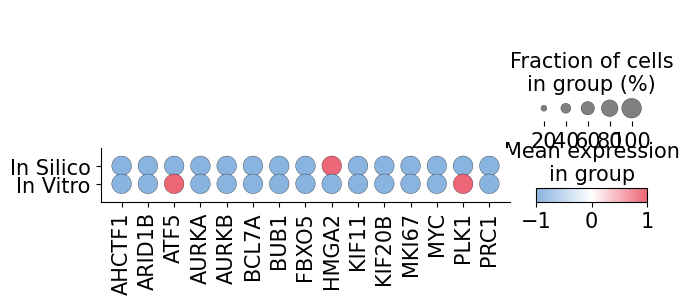

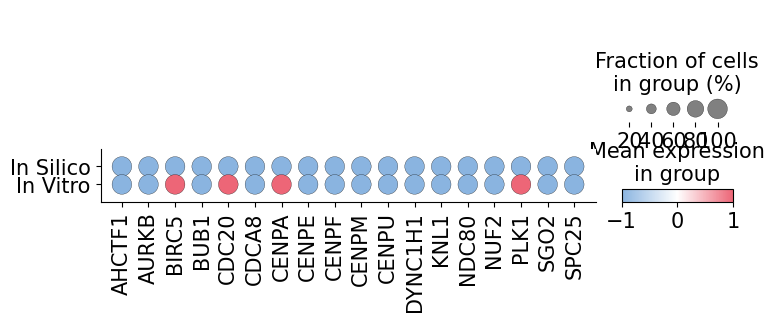

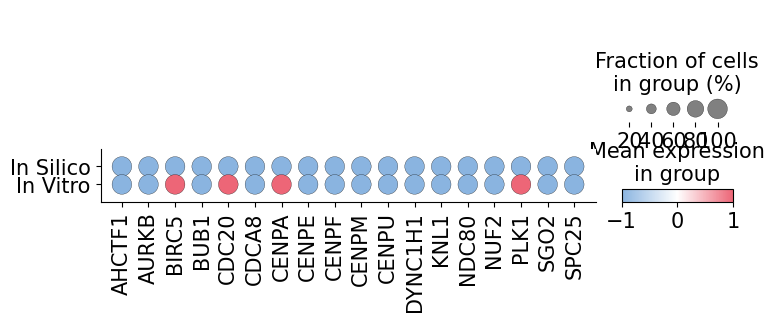

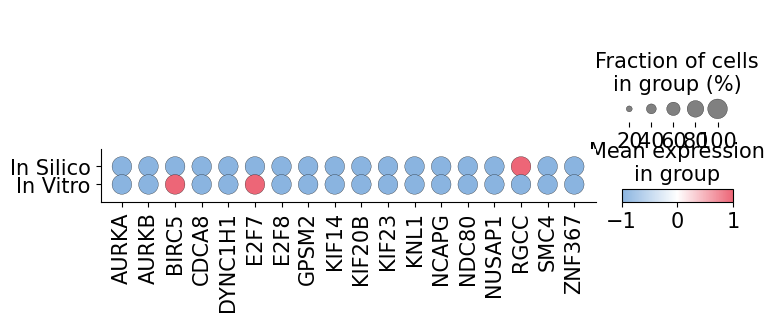

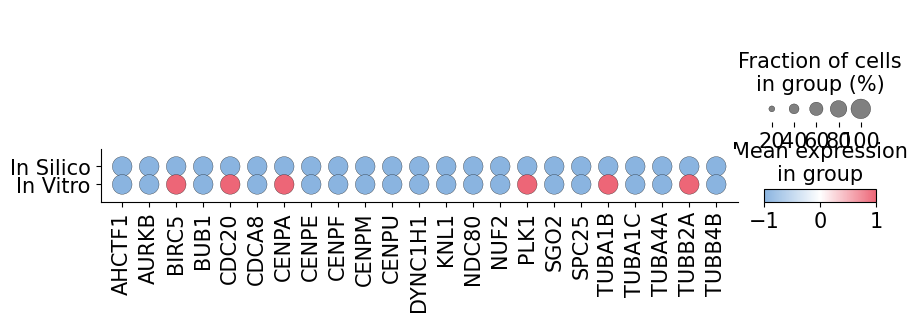

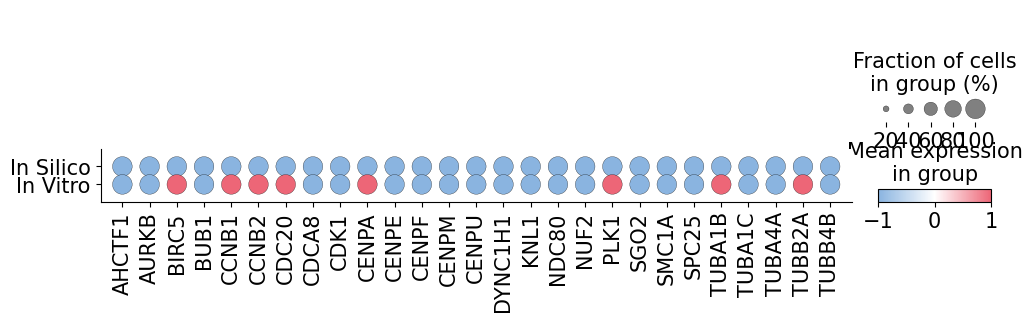

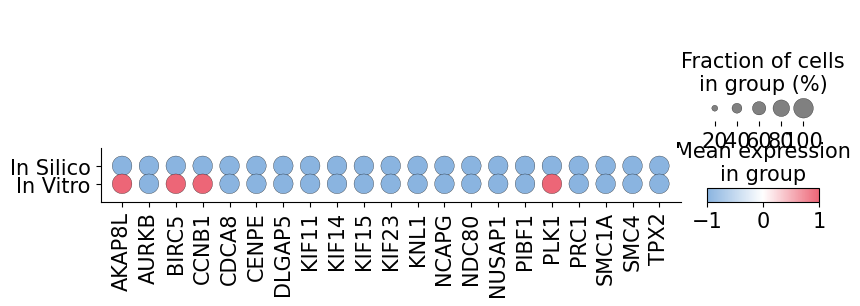

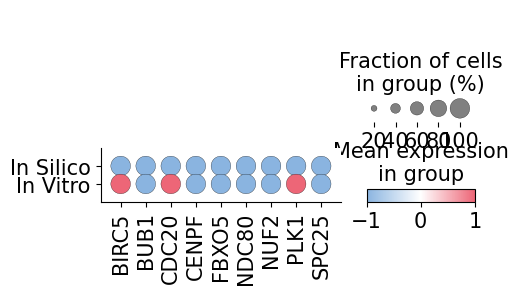

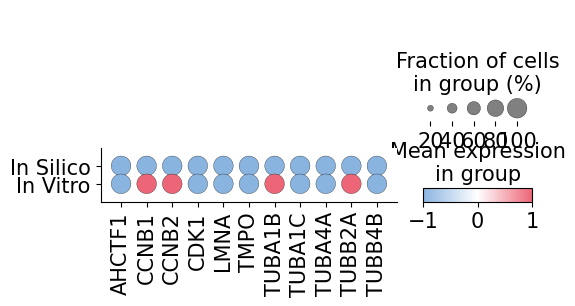

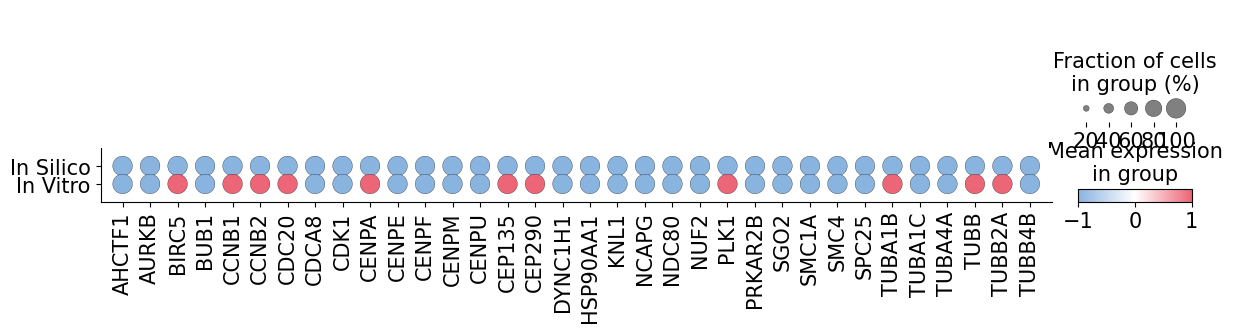

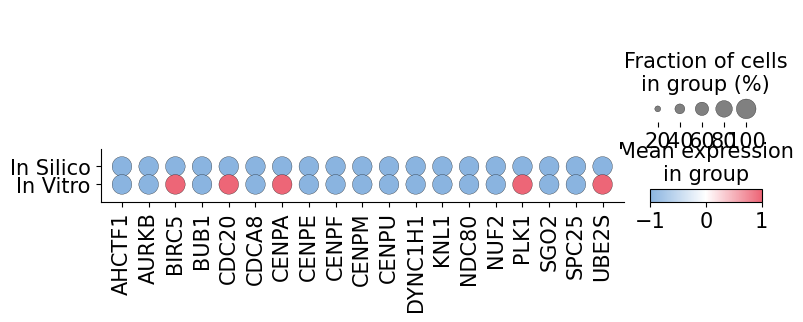

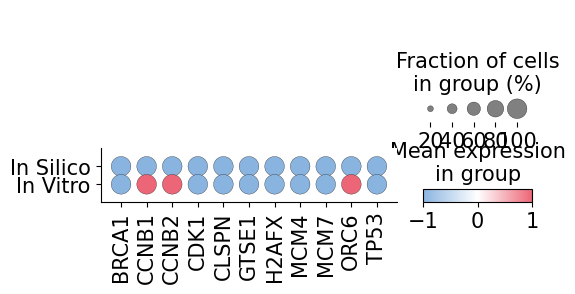

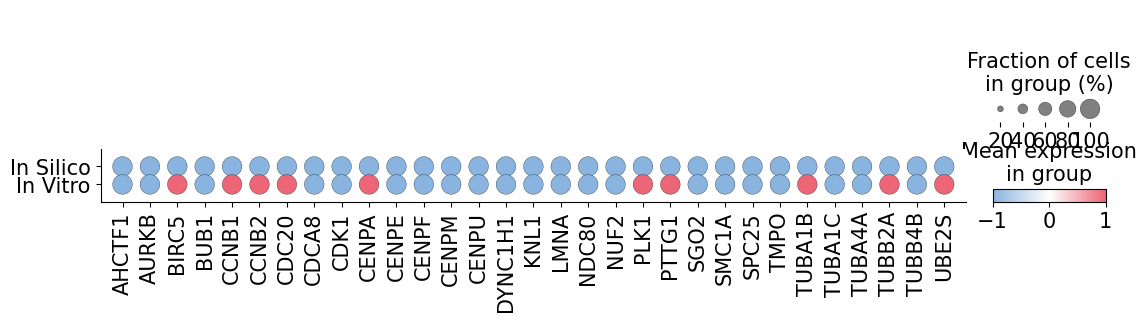

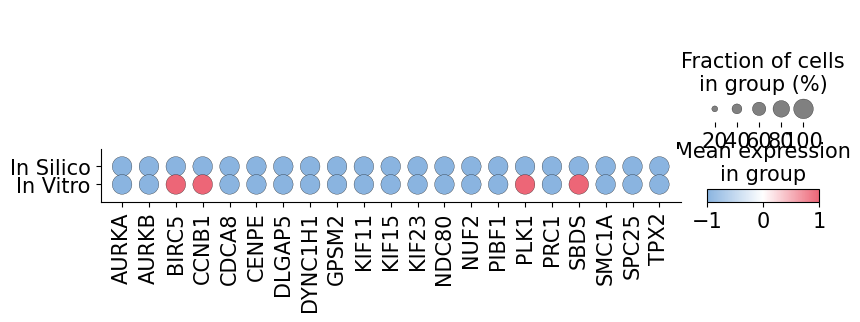

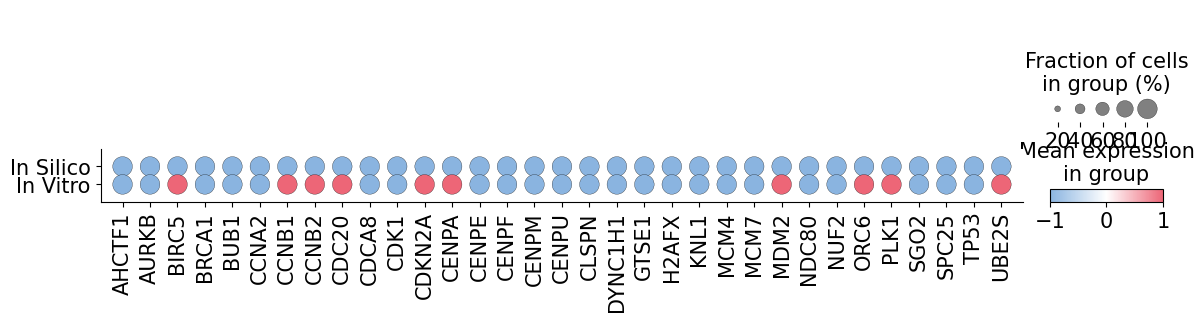

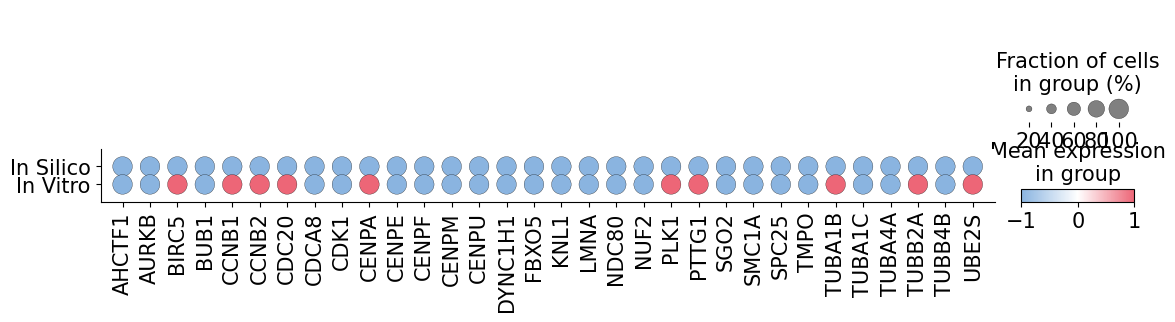

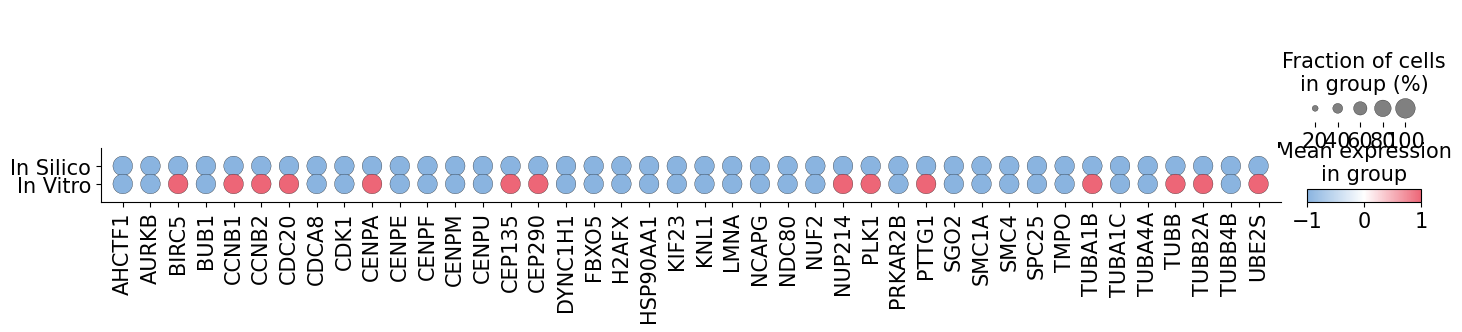

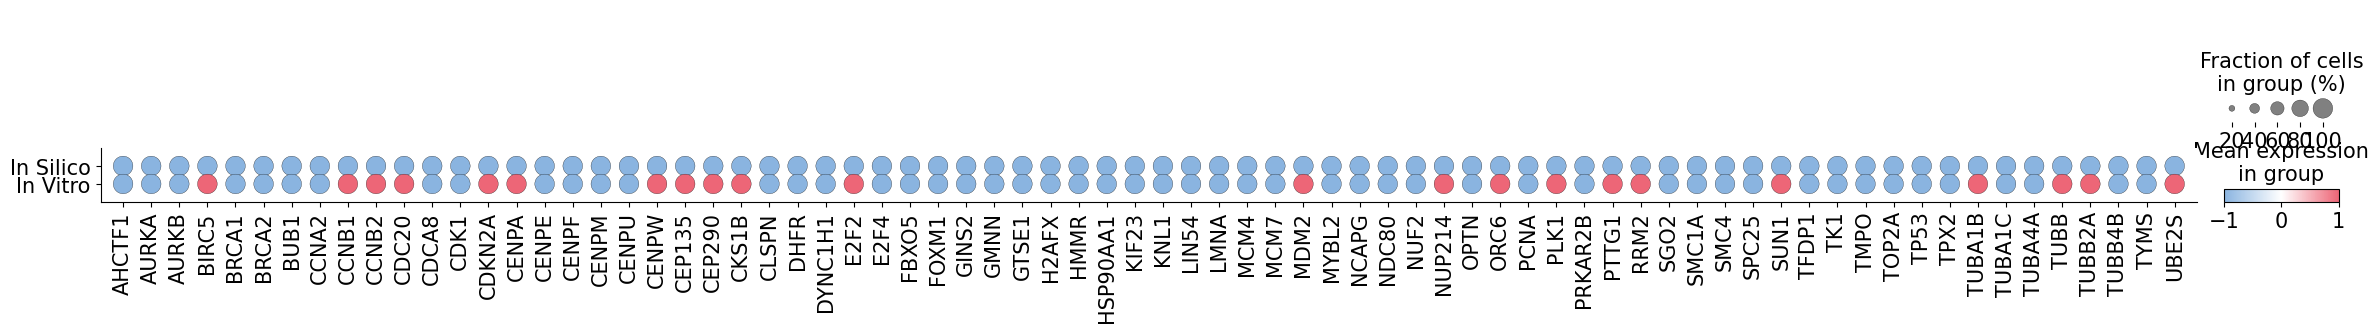

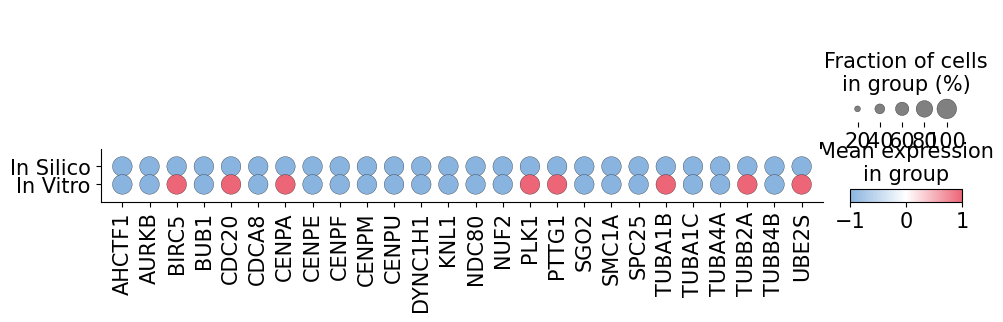

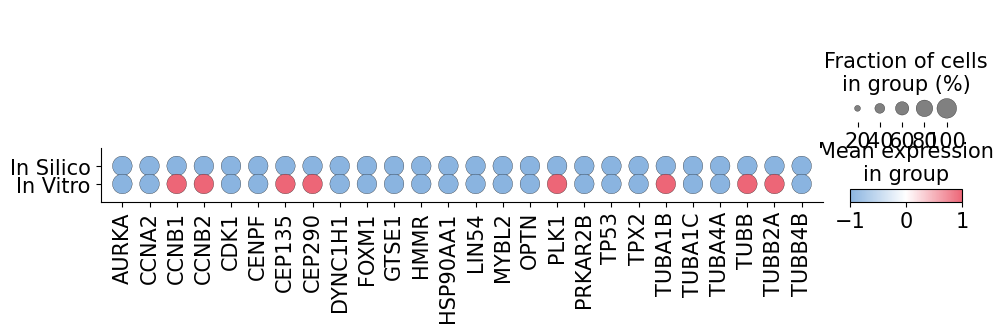

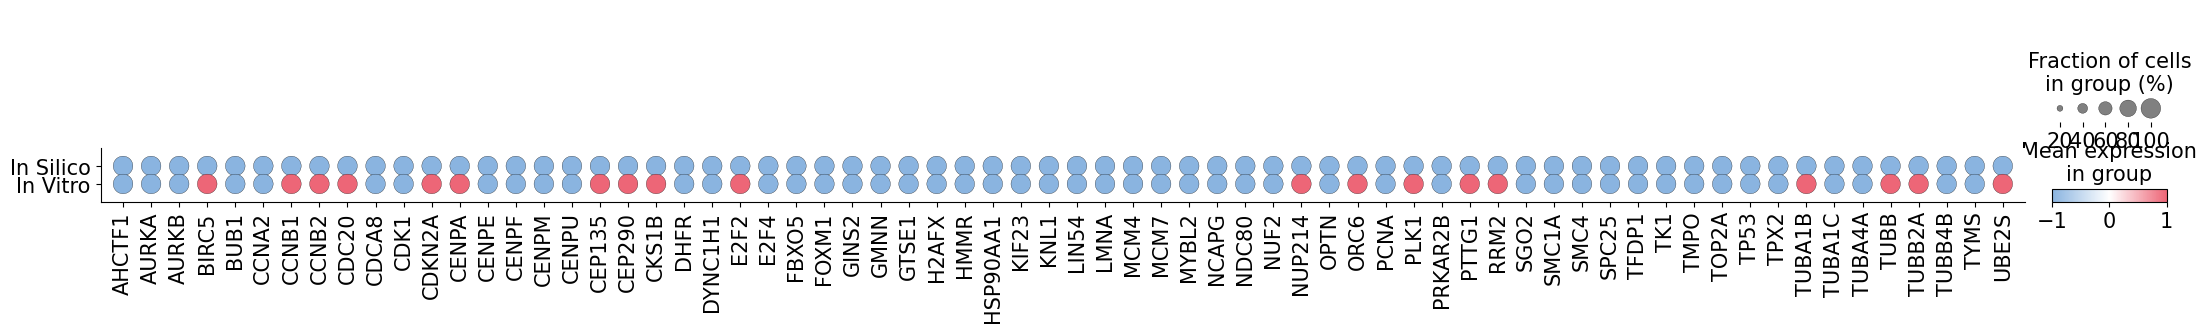

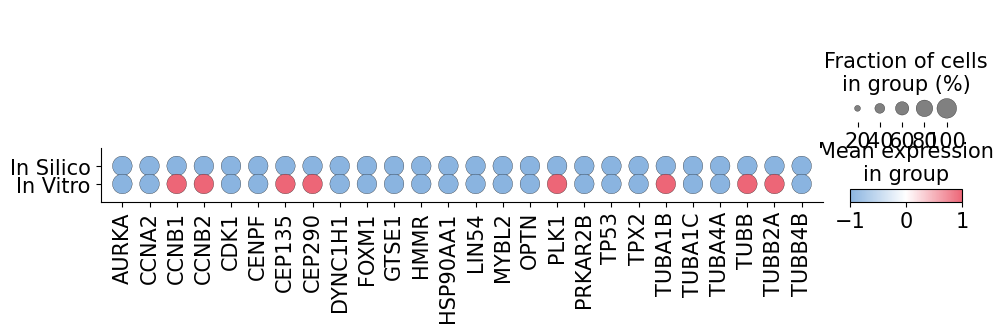

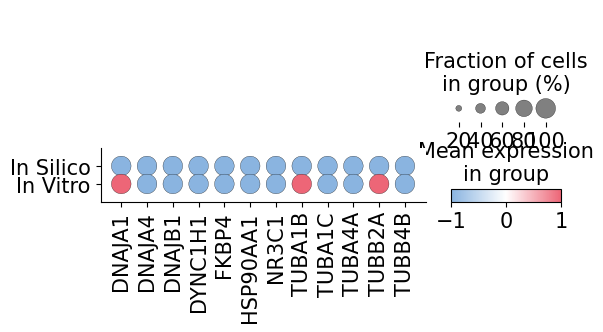

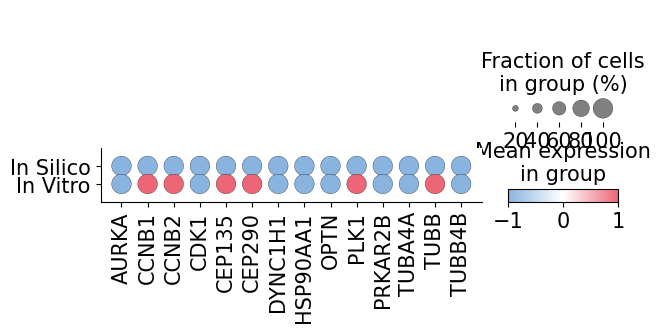

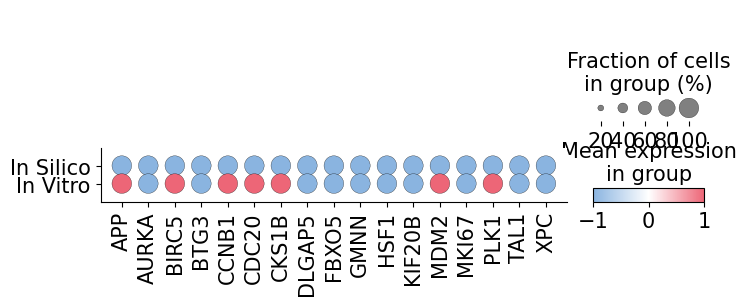

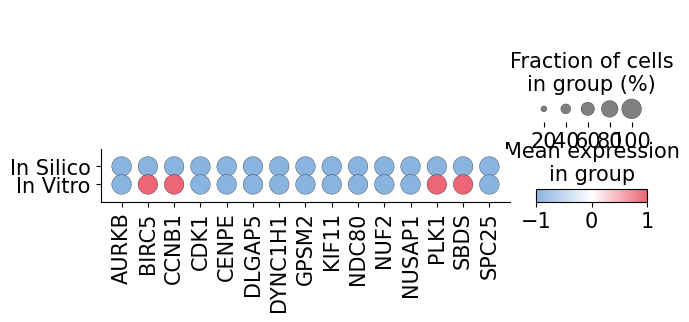

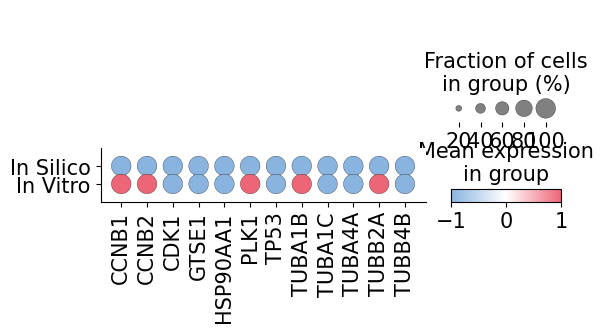

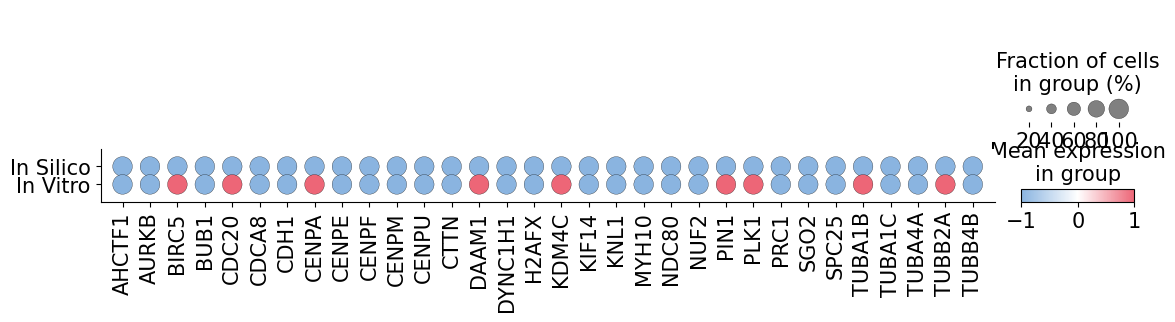

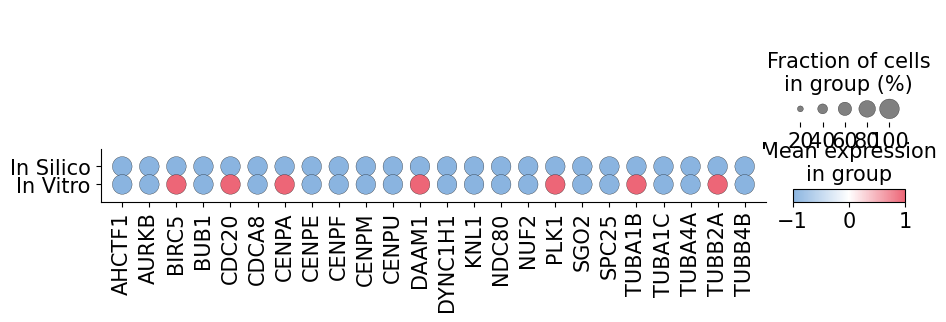

In [82]:
# plot top upr pathways
for term in concat_gsea_res_upr['Term']:
    plot_lead_gene_directionality(
        tf_deg_df,
        gata1_deg_df,
        concat_gsea_res,
        term=term,
    )
for term in concat_gsea_res_downr['Term']:
    plot_lead_gene_directionality(
        tf_deg_df,
        gata1_deg_df,
        concat_gsea_res,
        term=term,
    )